In [1]:
%load_ext autoreload
%autoreload 2
# For optimization
from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, GSTConfiguration, get_compressed_perturbed_rep_from_mgst, get_compressed_perturbed_kraus_from_superop, kraus_tensor_to_mgst, target_kraus_tensor_from_configuration, get_isometry_dimensions_from_tensor, tensor_to_isometry
from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.typing import TrustRegionOptions, OperatorSchedule
from mGST.visualization import plot_cost_function

# For vertical space testing
from mGST.gauge_analysis import random_vertical_velocity, generate_vertical_fundamental_vectors
from mGST.riemannian import is_in_tangent_space
from mGST.linear_algebra import generate_anti_hermitian_basis, is_anti_hermitian, compute_manual_rank
from mGST.additional_fns import randKrausSet
from mGST.visualization import COLOUR_PALETTE

import jax.numpy as jnp
import matplotlib.pyplot as plt

backend = "iqmfakeapollo"

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup (parameters, configuration and initial tensors)

In [2]:
depth = 7
num_shots = 1000
num_seq_2q = 900
kraus_rank_4 = 4
kraus_rank_16 = 16

num_qubits_2 = 2
dim_2q = 2 ** num_qubits_2
state_rank_2q = dim_2q
povm_rank_2q = dim_2q

# Running experiment

In [3]:
# This will be reused for all rank's in 2Q system. Since the rank passsed here is just symbolic.
# This rank is only accesed later from the data set to factorize into kraus psd (we do this manually outside)
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYICZ",
    num_circuits=num_seq_2q,
    shots=num_shots,
    rank=1,
)

kraus_tensor_mgst_2q_rank_1, kraus_mgst_2q_rank_1, povm_mgst_2q, state_mgst_2q, prob_matrix_2q, indices_list_2q = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

2026-06-16 11:10:01,970 - iqm.benchmarks.logging_config - INFO - Generating 900 random GST circuits
2026-06-16 11:10:02,536 - iqm.benchmarks.logging_config - INFO - Will transpile all 900 circuits according to fixed physical layout
2026-06-16 11:10:02,896 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-06-16 11:10:06,243 - iqm.benchmarks.logging_config - INFO - Submitting batch with 900 circuits corresponding to qubits [0, 1]
2026-06-16 11:10:06,252 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-06-16 11:10:06,310 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-06-16 11:10:06,335 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-06-16 11:10:07,433 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-06-16 11:10:09,345 - iqm.benchmarks.logging_config - INFO - Run complet

In [4]:
povm_psd_init_2q, state_psd_init_2q = get_compressed_perturbed_rep_from_mgst(povm_mgst_2q, state_mgst_2q)
cost_fn_kwargs_2q = {
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q,
    "jit": True,
}

In [5]:
# Obtain unperturbed Kraus
kraus_tensor_target = target_kraus_tensor_from_configuration(Q2_GST, backend)
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)
kraus_superop_target.shape, kraus_tensor_target.shape

((6, 16, 16), (6, 1, 4, 4))

In [6]:
# Now let's get the higher rank ones
kraus_tensor_init_2q_rank_16 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=16, seed=42)["kraus_tensor"]

# Gathering initial operators

In [7]:
init_operators_jax_2q_rank_16 = {
    "kraus_tensor_init": kraus_tensor_init_2q_rank_16,
    "povm_psd_init": povm_psd_init_2q,
    "state_psd_init": state_psd_init_2q,
}

initial_cost_value_rank_16 = cost_function_jax_mps(kraus_tensor_init_2q_rank_16, povm_psd_init_2q, state_psd_init_2q, **cost_fn_kwargs_2q)
print("Initial cost value (rank 16):", initial_cost_value_rank_16)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 43 the new count changed to: 4
at iteration 110 the new count changed to: 5
at iteration 178 the new count changed to: 6
at iteration 246 the new count changed to: 7
at iteration 314 the new count changed to: 8
at iteration 382 the new count changed to: 9
at iteration 450 the new count changed to: 10
at iteration 525 the new count changed to: 11
at iteration 600 the new count changed to: 12
at iteration 675 the new count changed to: 13
at iteration 750 the new count changed to: 14
at iteration 825 the new count changed to: 15
Initial cost value (rank 16): 0.0015192303978140737


In [8]:
[op.shape for op in init_operators_jax_2q_rank_16.values()]

[(6, 16, 4, 4), (4, 4, 4), (4, 4)]

# Optimization

## Setup

In [9]:
relative_precision = 1e-5
noise_threshold = estimate_noise_floor_threshold(cost_fn_kwargs_2q["prob_matrix"], num_shots=num_shots, multiplier=1.0)

print("Noise threshold: ", noise_threshold)

num_iterations_outer = 5
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-4
kappa = 1/10
theta = 1 # before by mistake we set it to 0.5 (WRONG)

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

Noise threshold:  0.00015537155166666668


{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

## Run

In [23]:
optimized_operators, cost_fn_history = run_riemannian_optimization(
    **init_operators_jax_2q_rank_16,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs_2q,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    relative_precision=relative_precision,
    noise_threshold=None, # do not stop if we go below this.
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.433827e-03. |r∇f(x)|: 2.339607e-03. Radius: 1.00e-01
TCG finished after: 4/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 2.70e-06
---------------------------------------
TR Iteration: 1. f(x): 1.364776e-03. |r∇f(x)|: 1.189691e-05. Radius: 1.00e-01
TCG finished after: 5/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 9.534928e-06
Optimization finished ✅. 
 Iters: 2. f(x): 1.364775e-03. |r∇f(x)|: 2.230798e-08. Radius: 2.00e-01. Rejections: 0

 🎯 [Povm] Relative change in cost function value: 6.90e-05. Target: 1.00e-05.
🚀 TR started for operat

## visualize trajecttory

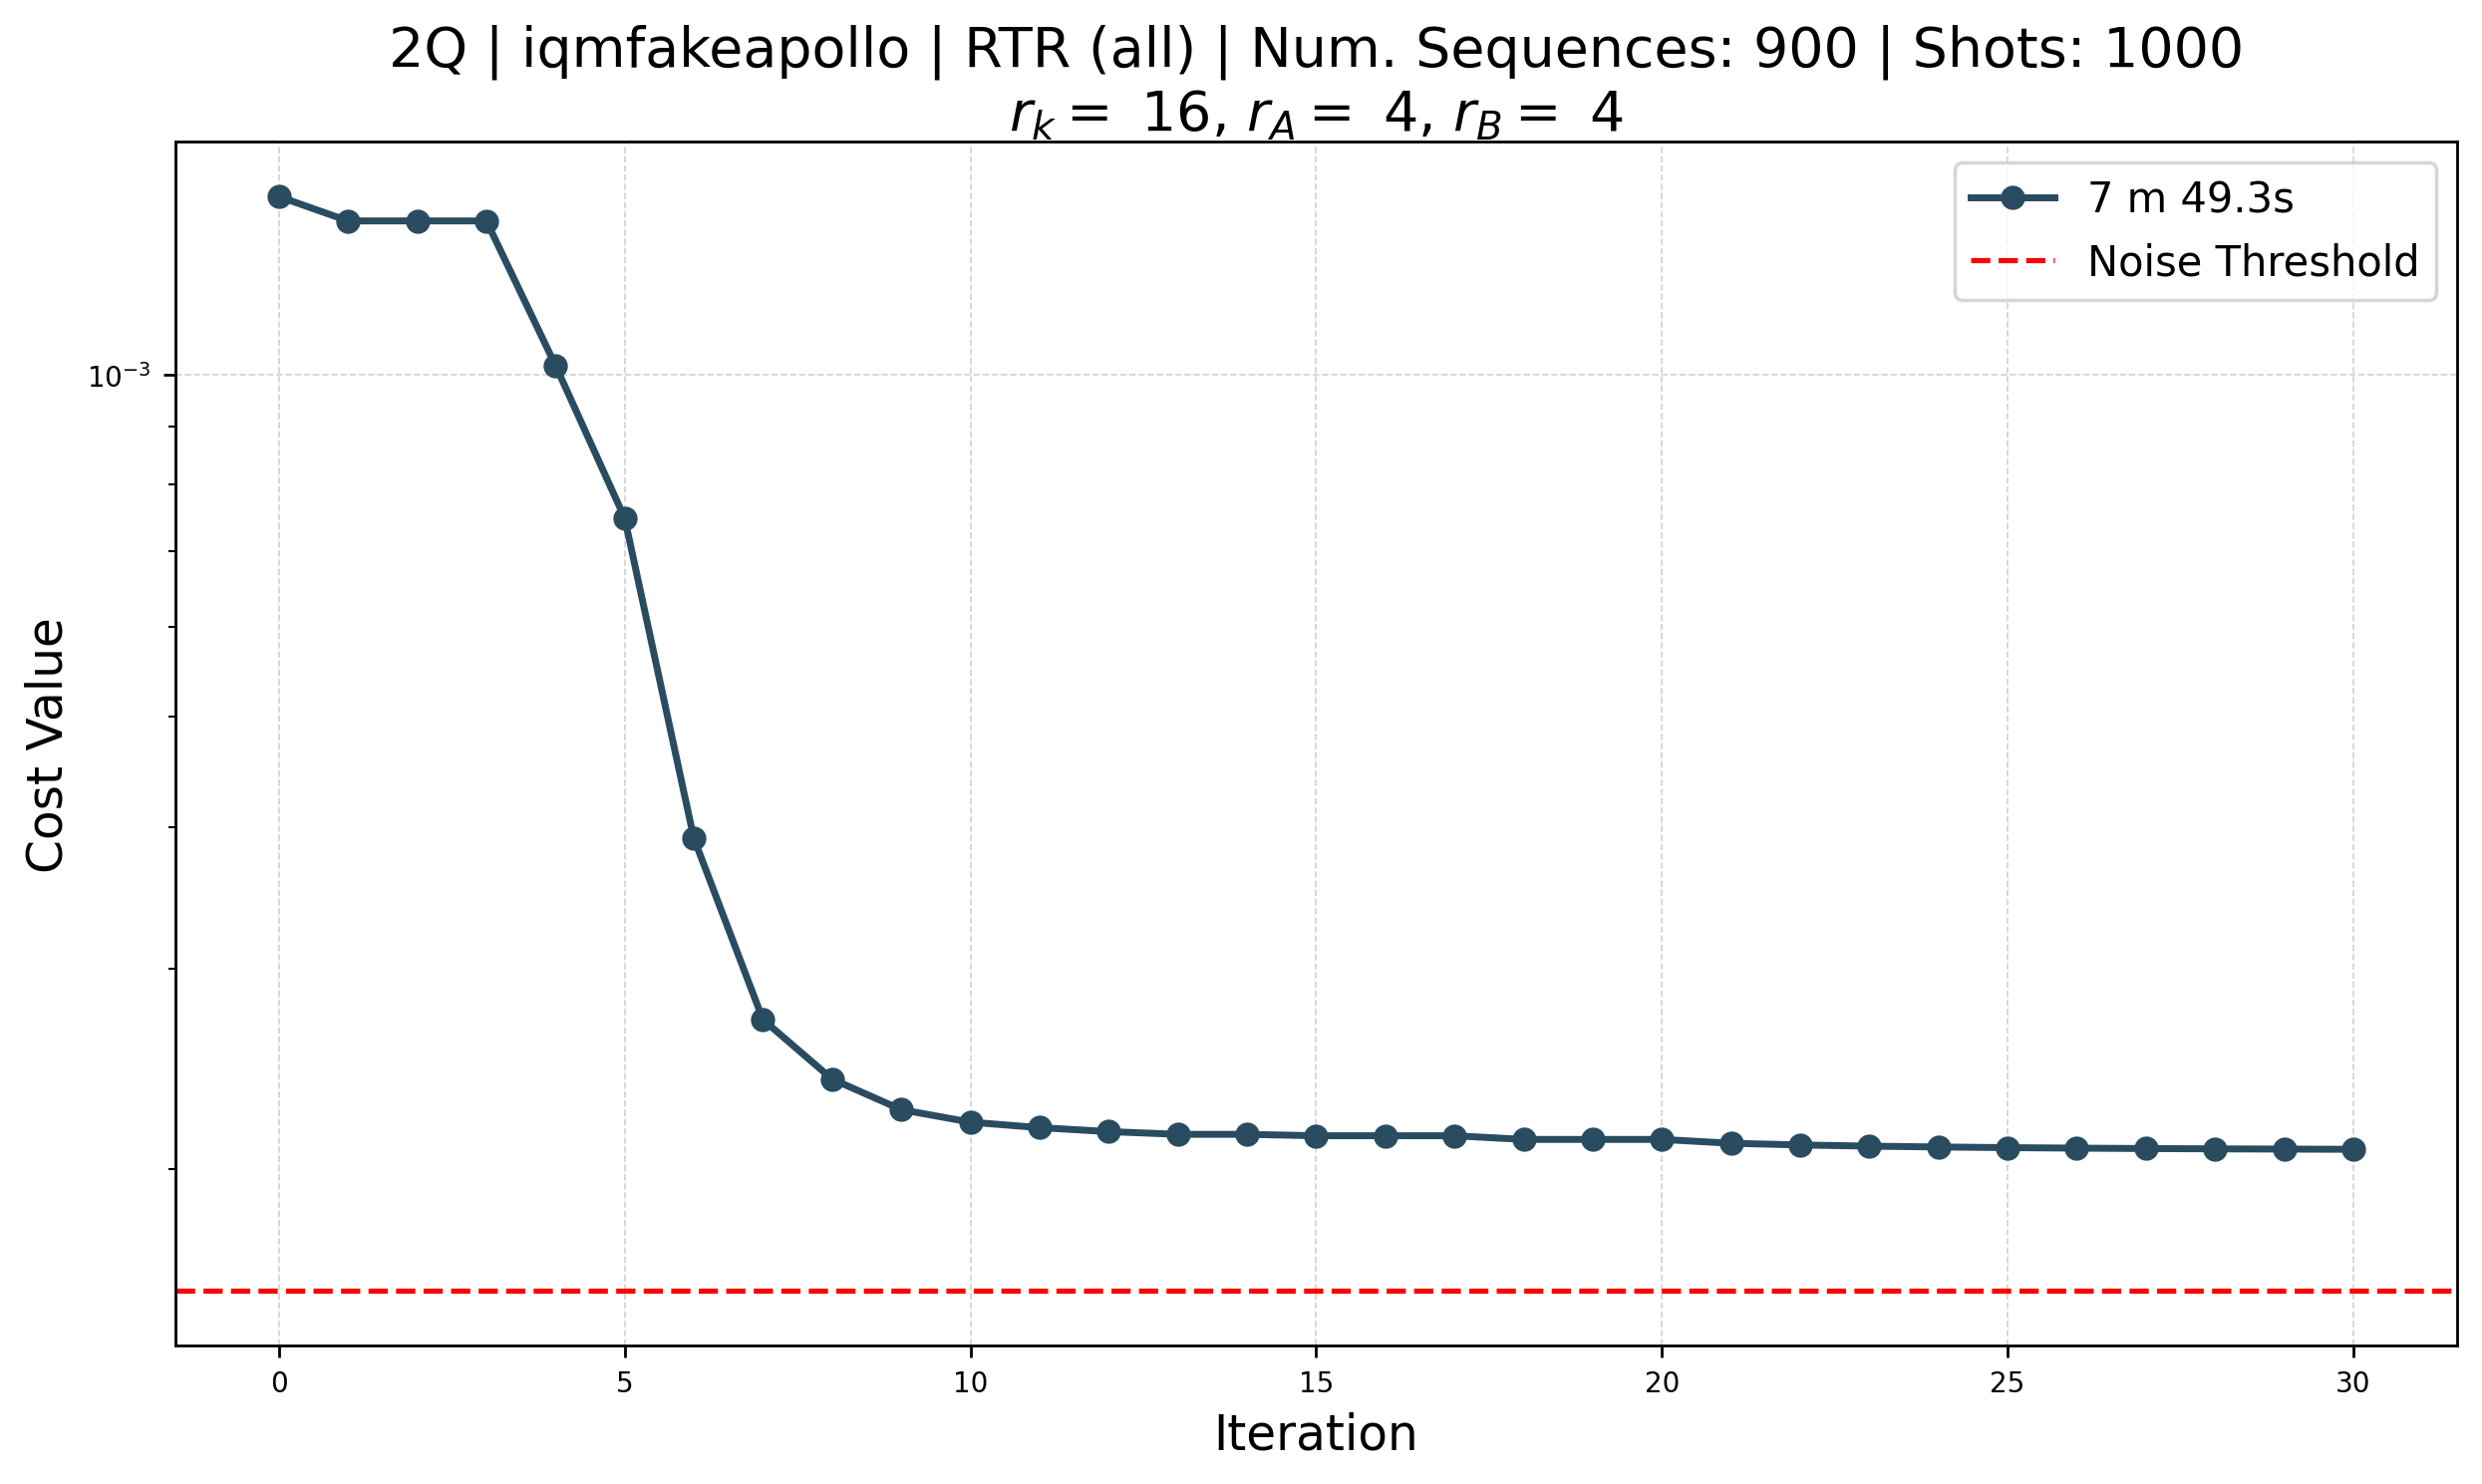

In [25]:
plot_cost_function(
    cost_array=[cost_fn_history],
    labels=[r"7 m 49.3s"],
    comparison_yline=noise_threshold,
    comparison_label="Noise Threshold",
    title=f"{num_qubits_2}Q | {backend} | RTR (all) | Num. Sequences: {num_seq_2q} | Shots: {num_shots}" + "\n" + rf"$r_k =$ {kraus_rank_16}, $r_A =$ {dim_2q}, $r_B =$ {dim_2q}"
)

# Vertical generators

# At initial point

## Setup

In [10]:
# single kraus tensor
x_init = init_operators_jax_2q_rank_16["kraus_tensor_init"]
print(x_init.shape)
x_init = x_init[0]

n, p = get_isometry_dimensions_from_tensor(x_init, operator_type="kraus")
x_isom_init = tensor_to_isometry(x_init, n, p)

(6, 16, 4, 4)


In [11]:
vert_velocity_rnd = random_vertical_velocity(x_isom_init, seed=42, dim_A=kraus_rank_16)
is_in_tangent_space(x=x_isom_init, z=vert_velocity_rnd)

Array(True, dtype=bool)

In [12]:
# check anti-hermitian basis
anti_hermitian_basis = generate_anti_hermitian_basis(dim=kraus_rank_16)
print(anti_hermitian_basis.shape)
all(is_anti_hermitian(A) for A in anti_hermitian_basis)

(256, 16, 16)


True

In [13]:
# construct the fundamental vertical vectors from this basis
vertical_fundamental_vectors = generate_vertical_fundamental_vectors(x=x_isom_init, dim_A=kraus_rank_16)
print(vertical_fundamental_vectors.shape)
all(is_in_tangent_space(x=x_isom_init, z=v) for v in vertical_fundamental_vectors)

(256, 64, 4)


True

In [14]:
# We now have to vectorize this basis
vect_vertical_fundamental_vectors = vertical_fundamental_vectors.reshape(vertical_fundamental_vectors.shape[0], -1)
print(vect_vertical_fundamental_vectors.shape)

(256, 256)


In [15]:
# do we stack the real and imaginary part or do we use the wirtinger representation?
vect_vertical_fundamental_vectors_real = jnp.concatenate([vect_vertical_fundamental_vectors.real, vect_vertical_fundamental_vectors.imag], axis=1)
print(vect_vertical_fundamental_vectors_real.shape)

(256, 512)


In [16]:
vect_vertical_fundamental_vectors_wirtinger = jnp.concatenate([vect_vertical_fundamental_vectors, jnp.conj(vect_vertical_fundamental_vectors)], axis=1)
print(vect_vertical_fundamental_vectors_wirtinger.shape)

(256, 512)


In [17]:
tol = 1e-6
rank_real, s_values_real = compute_manual_rank(vect_vertical_fundamental_vectors_real, tol=tol)
print("Vertical space dimension: ", rank_real)

Vertical space dimension:  256


In [18]:
rank_complex, s_values_complex = compute_manual_rank(vect_vertical_fundamental_vectors, tol=tol)
print("Vertical space dimension: ", rank_complex)

Vertical space dimension:  256


In [19]:
rank_wirtinger, s_values_wirtinger = compute_manual_rank(vect_vertical_fundamental_vectors_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_wirtinger)

Vertical space dimension:  256


## Visualization

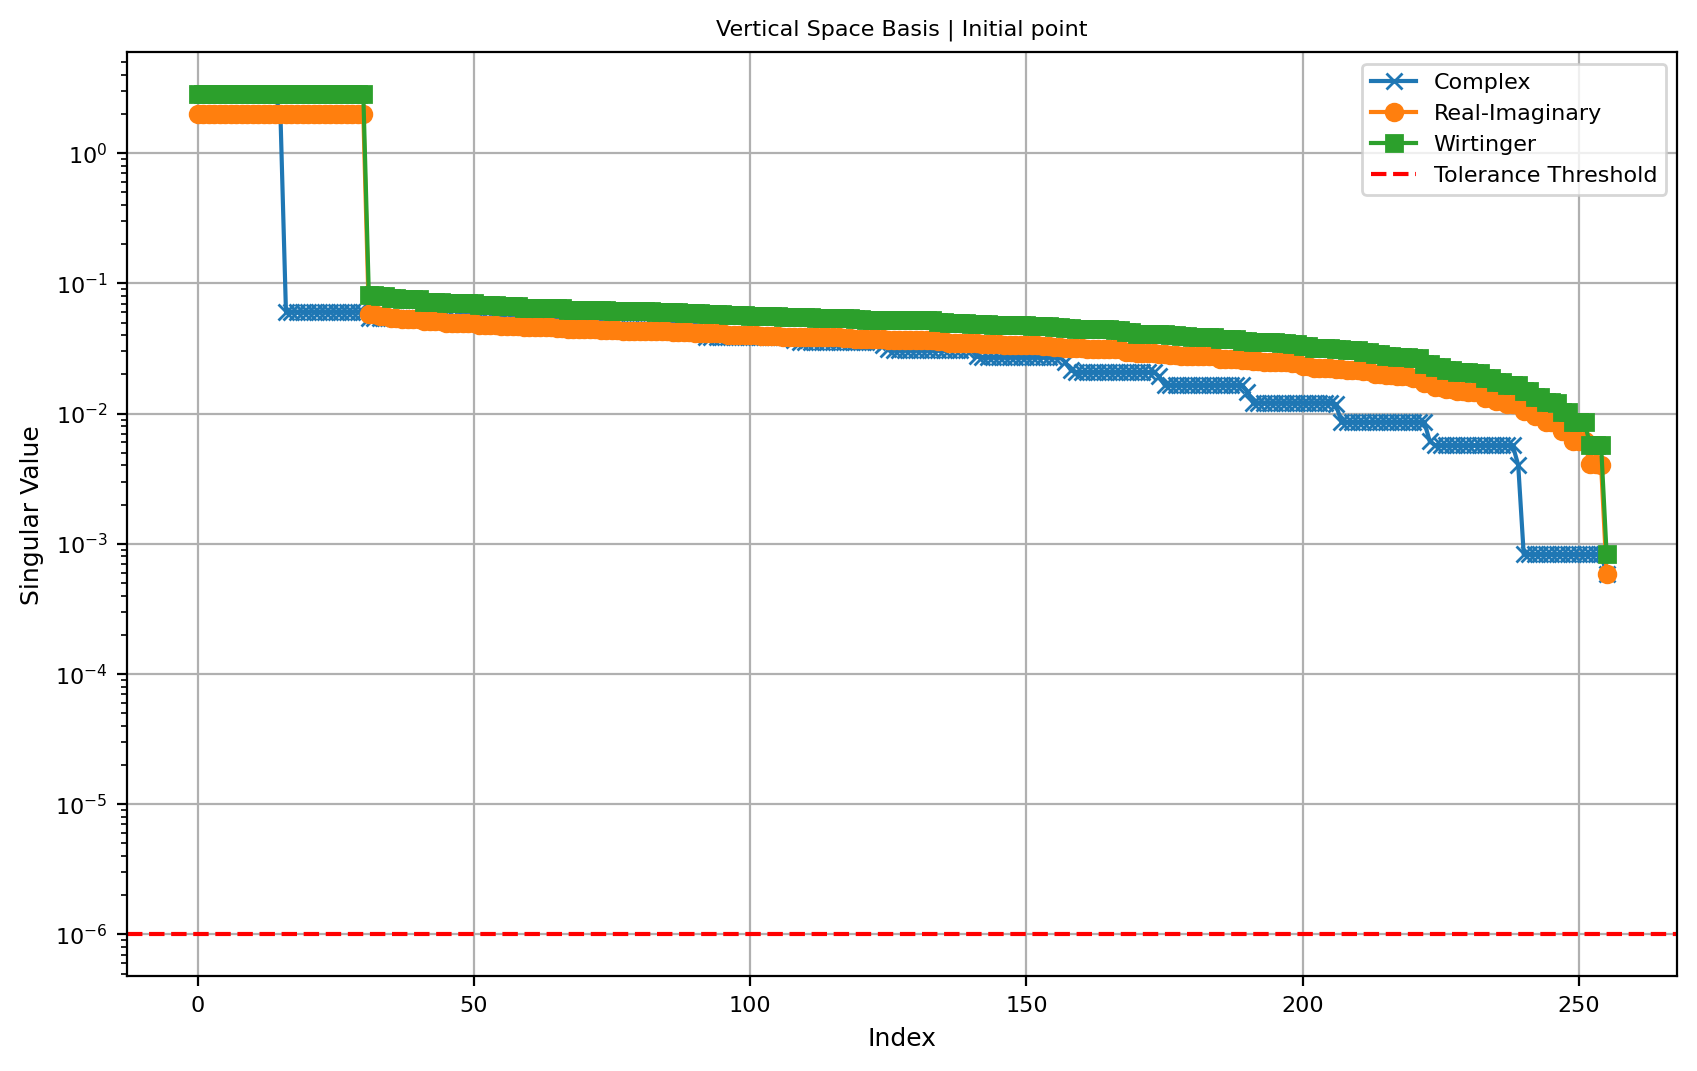

In [20]:
# plot the singular values:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_complex, marker='x', label="Complex")
plt.semilogy(s_values_real, marker='o', label="Real-Imaginary")
plt.semilogy(s_values_wirtinger, marker='s', label="Wirtinger")
plt.axhline(tol, color='red', linestyle='--', label='Tolerance Threshold')
plt.title('Vertical Space Basis | Initial point')
plt.xlabel('Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True)
plt.show()

# At final point

In [93]:
# single kraus tensor
x_opt = optimized_operators["kraus"][0]
print(x_opt.shape)
x_isom_opt = tensor_to_isometry(x_opt, n, p)
print(x_isom_opt.shape)

# construct the fundamental vertical vectors from this basis
vert_fund_vects_opt = generate_vertical_fundamental_vectors(x=x_isom_opt, dim_A=kraus_rank_16)
print(vert_fund_vects_opt.shape)
all(is_in_tangent_space(x=x_isom_opt, z=v) for v in vert_fund_vects_opt)

(16, 4, 4)
(64, 4)
(256, 64, 4)


True

In [99]:
vert_basis_opt_complex = vert_fund_vects_opt.reshape(vert_fund_vects_opt.shape[0], -1)
vert_basis_opt_real = jnp.concatenate([vert_basis_opt_complex.real, vert_basis_opt_complex.imag], axis=1)
vert_bassis_opt_wirtinger = jnp.concatenate([vert_basis_opt_complex, jnp.conj(vert_basis_opt_complex)], axis=1)

In [109]:
tol = 1e-6

rank_opt_real, s_values_opt_real = compute_manual_rank(vert_basis_opt_real, tol=tol)
print("Vertical space dimension: ", rank_opt_real)

rank_opt_complex, s_values_opt_complex = compute_manual_rank(vert_basis_opt_complex, tol=tol)
print("Vertical space dimension: ", rank_opt_complex)

rank_opt_wirtinger, s_values_opt_wirtinger = compute_manual_rank(vert_bassis_opt_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_opt_wirtinger)

Vertical space dimension:  255
Vertical space dimension:  240
Vertical space dimension:  255


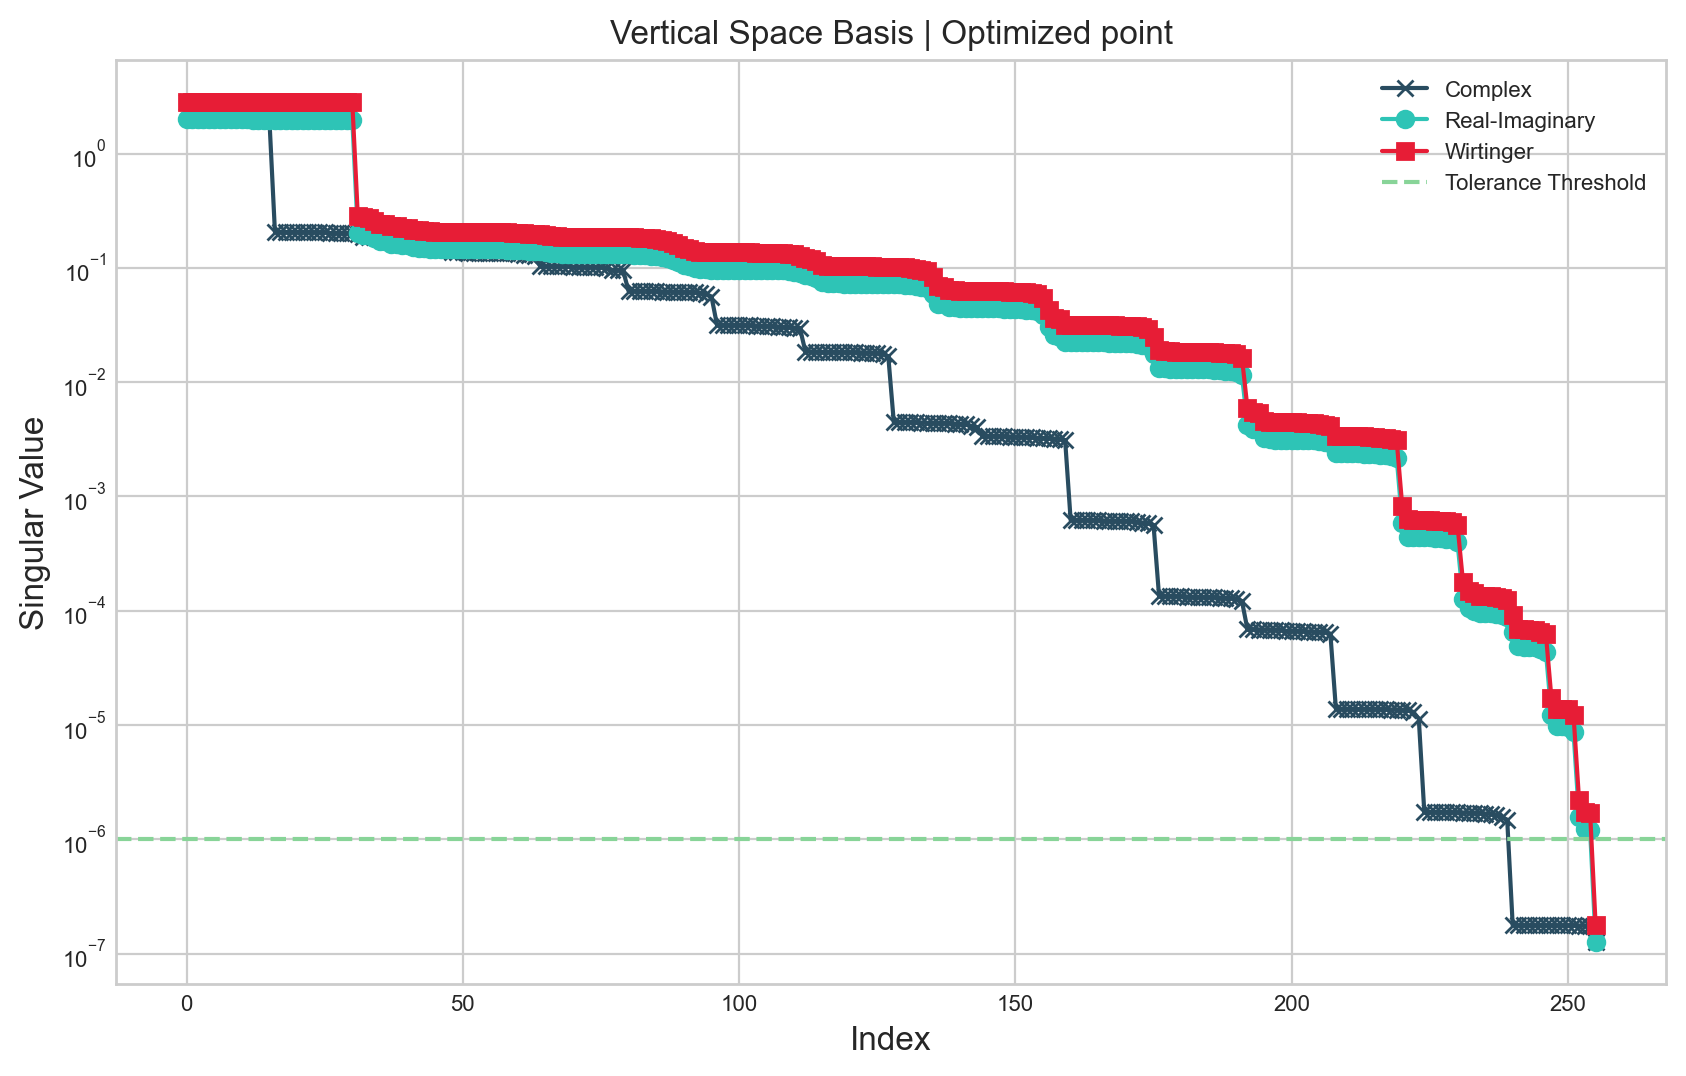

In [188]:
# plot the singular values:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_opt_complex, marker='x', label="Complex", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_opt_real, marker='o', label="Real-Imaginary", color=COLOUR_PALETTE[1])
plt.semilogy(s_values_opt_wirtinger, marker='s', label="Wirtinger", color=COLOUR_PALETTE[2])
plt.axhline(tol, linestyle='--', label='Tolerance Threshold', color=COLOUR_PALETTE[3])
plt.title('Vertical Space Basis | Optimized point', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# At random point

In [21]:
step_size = 1e-8
random_kraus_tensor = randKrausSet(num_gate_sequences=5, dim=dim_2q, rank_kraus=kraus_rank_16, a=step_size, seed=42)
idx = 0
x_rnd = random_kraus_tensor[idx]
x_rnd_isom = tensor_to_isometry(x_rnd, n, p)
print(x_rnd.shape)

# construct the fundamental vertical vectors from this basis
vert_fund_vects_rnd = generate_vertical_fundamental_vectors(x=x_rnd_isom, dim_A=kraus_rank_16)
print(vert_fund_vects_rnd.shape)
all(is_in_tangent_space(x=x_rnd_isom, z=v) for v in vert_fund_vects_rnd)

(16, 4, 4)
(256, 64, 4)


True

In [22]:
vert_basis_rnd_complex = vert_fund_vects_rnd.reshape(vert_fund_vects_rnd.shape[0], -1)
vert_basis_rnd_real = jnp.concatenate([vert_basis_rnd_complex.real, vert_basis_rnd_complex.imag], axis=1)
vert_basis_rnd_wirtinger = jnp.concatenate([vert_basis_rnd_complex, jnp.conj(vert_basis_rnd_complex)], axis=1)

In [23]:
tol = 1e-6
rank_rnd_real, s_values_rnd_real = compute_manual_rank(vert_basis_rnd_real, tol=tol)
print("Vertical space dimension: ", rank_rnd_real)

rank_rnd_complex, s_values_rnd_complex = compute_manual_rank(vert_basis_rnd_complex, tol=tol)
print("Vertical space dimension: ", rank_rnd_complex)

rank_rnd_wirtinger, s_values_rnd_wirtinger = compute_manual_rank(vert_basis_rnd_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_rnd_wirtinger)

Vertical space dimension:  31
Vertical space dimension:  16
Vertical space dimension:  31


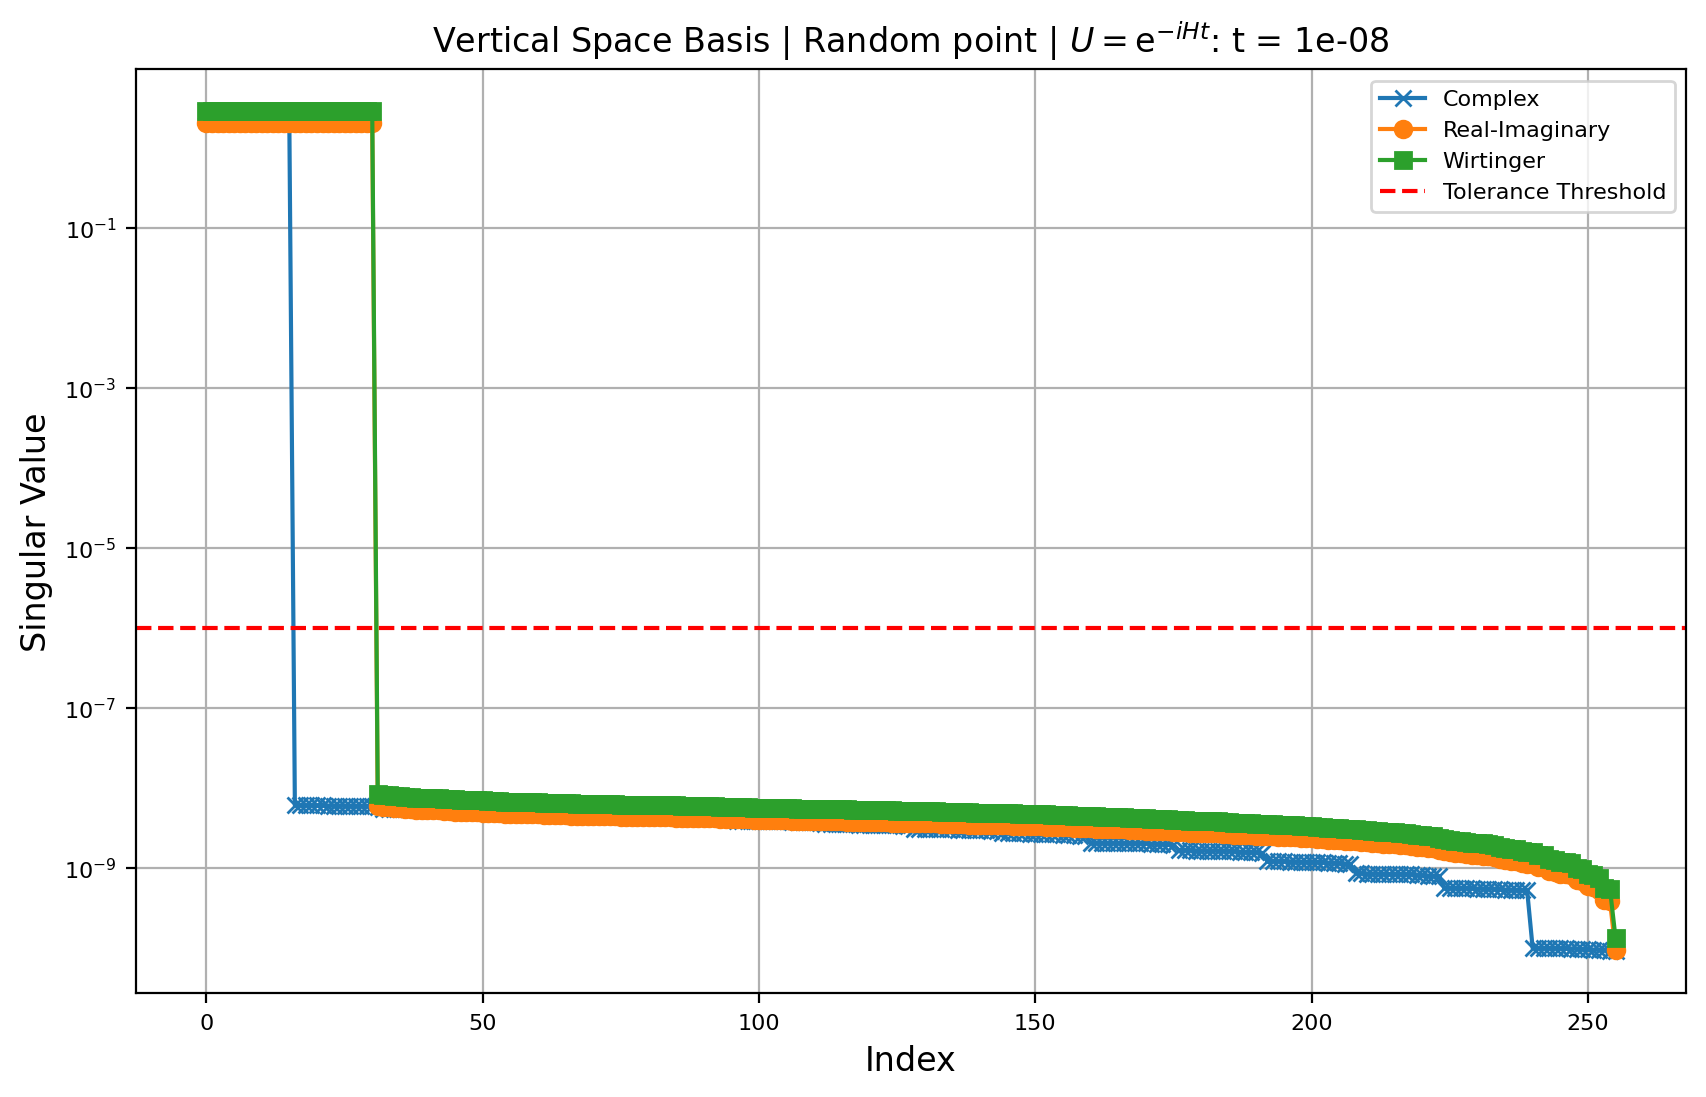

In [24]:
# plot the singular values:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_rnd_complex, marker='x', label="Complex")
plt.semilogy(s_values_rnd_real, marker='o', label="Real-Imaginary")
plt.semilogy(s_values_rnd_wirtinger, marker='s', label="Wirtinger")
plt.axhline(tol, color='red', linestyle='--', label='Tolerance Threshold')
plt.title(r'Vertical Space Basis | Random point | $U = \mathrm{e}^{-iHt}$' + f': t = {step_size}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [25]:
kraus_rank_16

16

# All together:

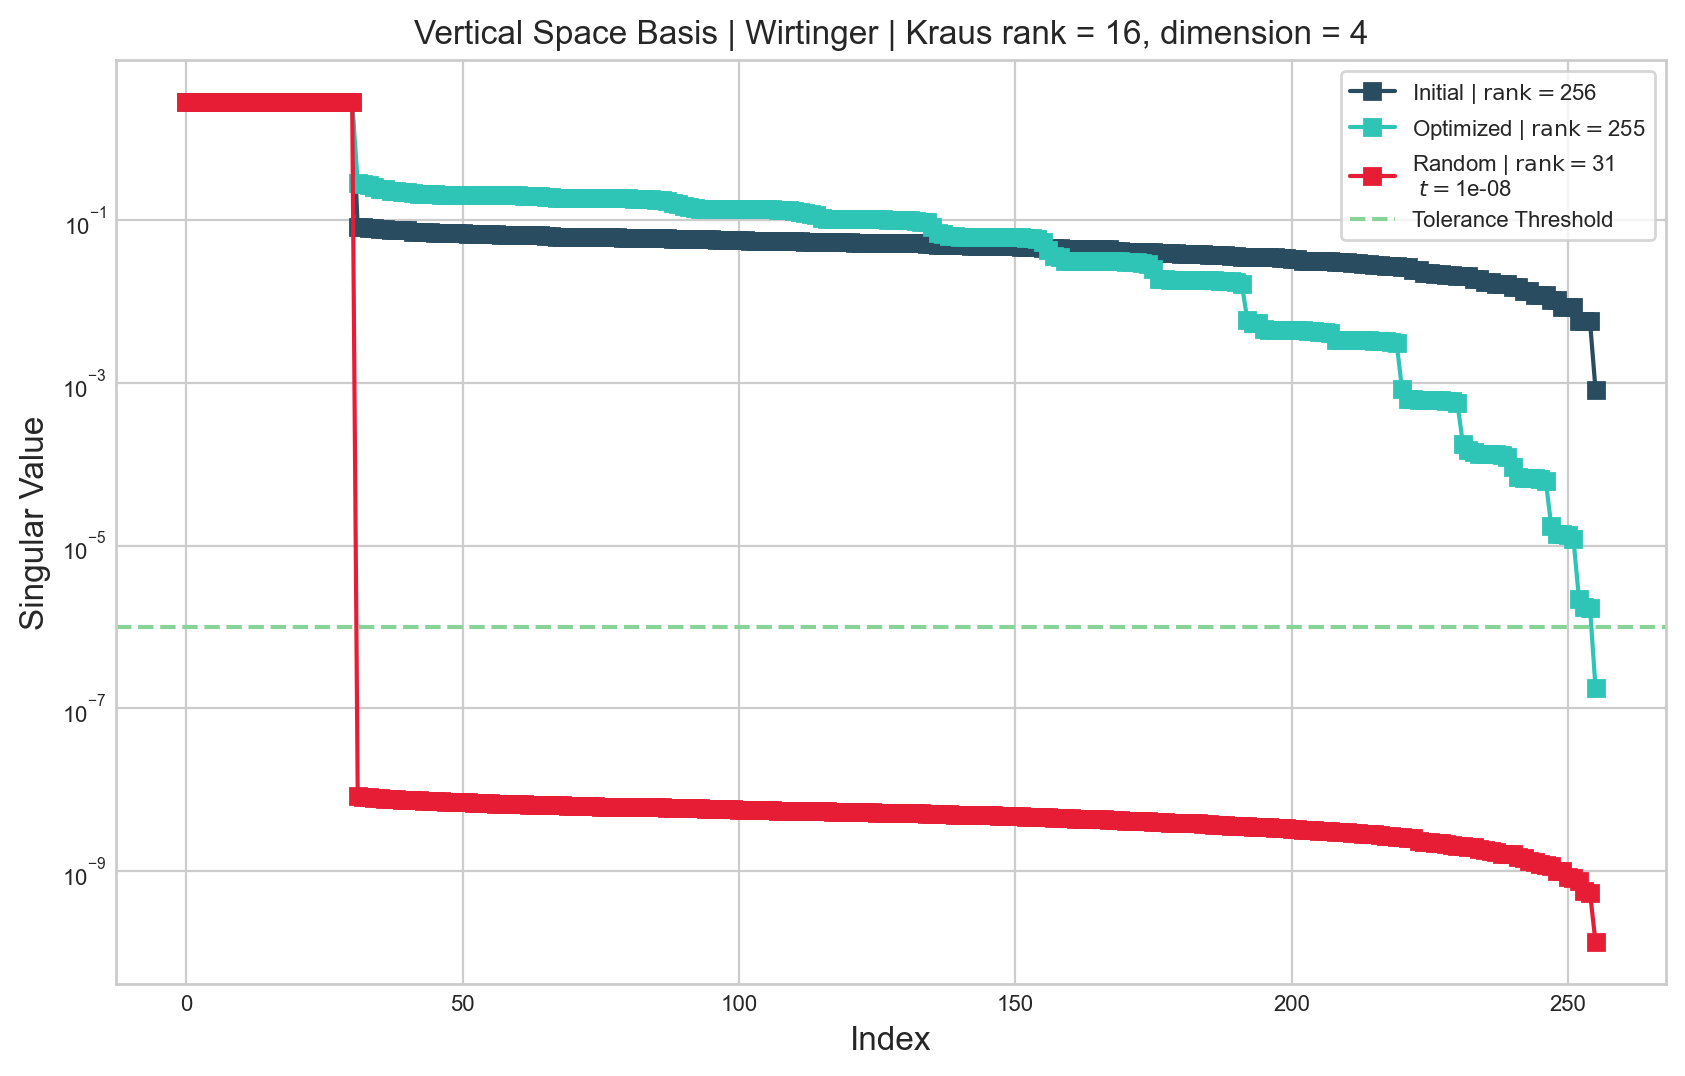

In [218]:
# plot the singular values:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_wirtinger, marker='s', label=r"Initial | $\mathrm{rank} = $" + f"{rank_wirtinger}", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_opt_wirtinger, marker='s', label=r"Optimized | $\mathrm{rank} = $" + f"{rank_opt_wirtinger}", color=COLOUR_PALETTE[1])
plt.semilogy(s_values_rnd_wirtinger, marker='s', label=r"Random | $\mathrm{rank} = $" + f"{rank_rnd_wirtinger} \n" + r" $t=$" + f"{step_size}", color=COLOUR_PALETTE[2])
plt.axhline(tol, color=COLOUR_PALETTE[3], linestyle='--', label='Tolerance Threshold')
plt.title(f'Vertical Space Basis | Wirtinger | Kraus rank = {kraus_rank_16}, dimension = {dim_2q}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend(frameon=True)
plt.grid(True)
plt.show()

In [256]:
# count the number of values that are greater than 1
jnp.sum(s_values_opt_wirtinger > 1), jnp.sum(s_values_rnd_wirtinger > 1), jnp.sum(s_values_wirtinger > 1)

(Array(31, dtype=int64), Array(31, dtype=int64), Array(31, dtype=int64))

### Additional plotting of singular values

In [202]:
def plot_singular_value_distributions(
    singular_value_dict,
    tol=None,
    bins=28,
    title="Distribution of Singular Values",
    palette=COLOUR_PALETTE,
):
    """
    Plot overlapping histogram distributions of singular values on log10 scale.

    Parameters
    ----------
    singular_value_dict : dict[str, array-like]
        Mapping from label to singular values.
    tol : float | None
        Optional tolerance threshold to display as a vertical line.
    bins : int
        Number of histogram bins.
    title : str
        Plot title.
    palette : list[str] | None
        List of colors to use. If fewer colors than datasets are provided,
        colors are repeated cyclically.
    """
    plt.style.use("seaborn-v0_8-whitegrid")

    eps = 1e-16
    labels = list(singular_value_dict.keys())
    values = [jnp.asarray(v) for v in singular_value_dict.values()]
    log_values = [jnp.log10(jnp.clip(v, eps, None)) for v in values]

    all_logs = jnp.concatenate(log_values)
    bin_edges = jnp.linspace(all_logs.min(), all_logs.max(), bins + 1)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

    for i, (label, log_vals) in enumerate(zip(labels, log_values)):
        color = palette[i % len(palette)]

        ax.hist(
            log_vals,
            bins=bin_edges,
            density=True,
            alpha=0.28,
            color=color,
            edgecolor=color,
            linewidth=1.2,
            label=label,
        )

        ax.hist(
            log_vals,
            bins=bin_edges,
            density=True,
            histtype="step",
            color=color,
            linewidth=2.0,
        )

        ax.axvline(
            log_vals.mean(),
            color=color,
            linestyle="--",
            linewidth=1.8,
            alpha=0.9,
        )

    if tol is not None and tol > 0:
        ax.axvline(
            jnp.log10(tol),
            color="black",
            linestyle=":",
            linewidth=2,
            alpha=0.85,
            label=rf"$\log_{{10}}(\mathrm{{tol}})$ = {jnp.log10(tol):.2f}",
        )

    ax.set_title(title, fontsize=15, pad=14, fontweight="semibold")
    ax.set_xlabel(r"$\log_{10}(\sigma)$", fontsize=13)
    ax.set_ylabel("Density", fontsize=13)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.22, linewidth=0.8)
    ax.legend(frameon=False, fontsize=11)

    plt.tight_layout()
    plt.show()

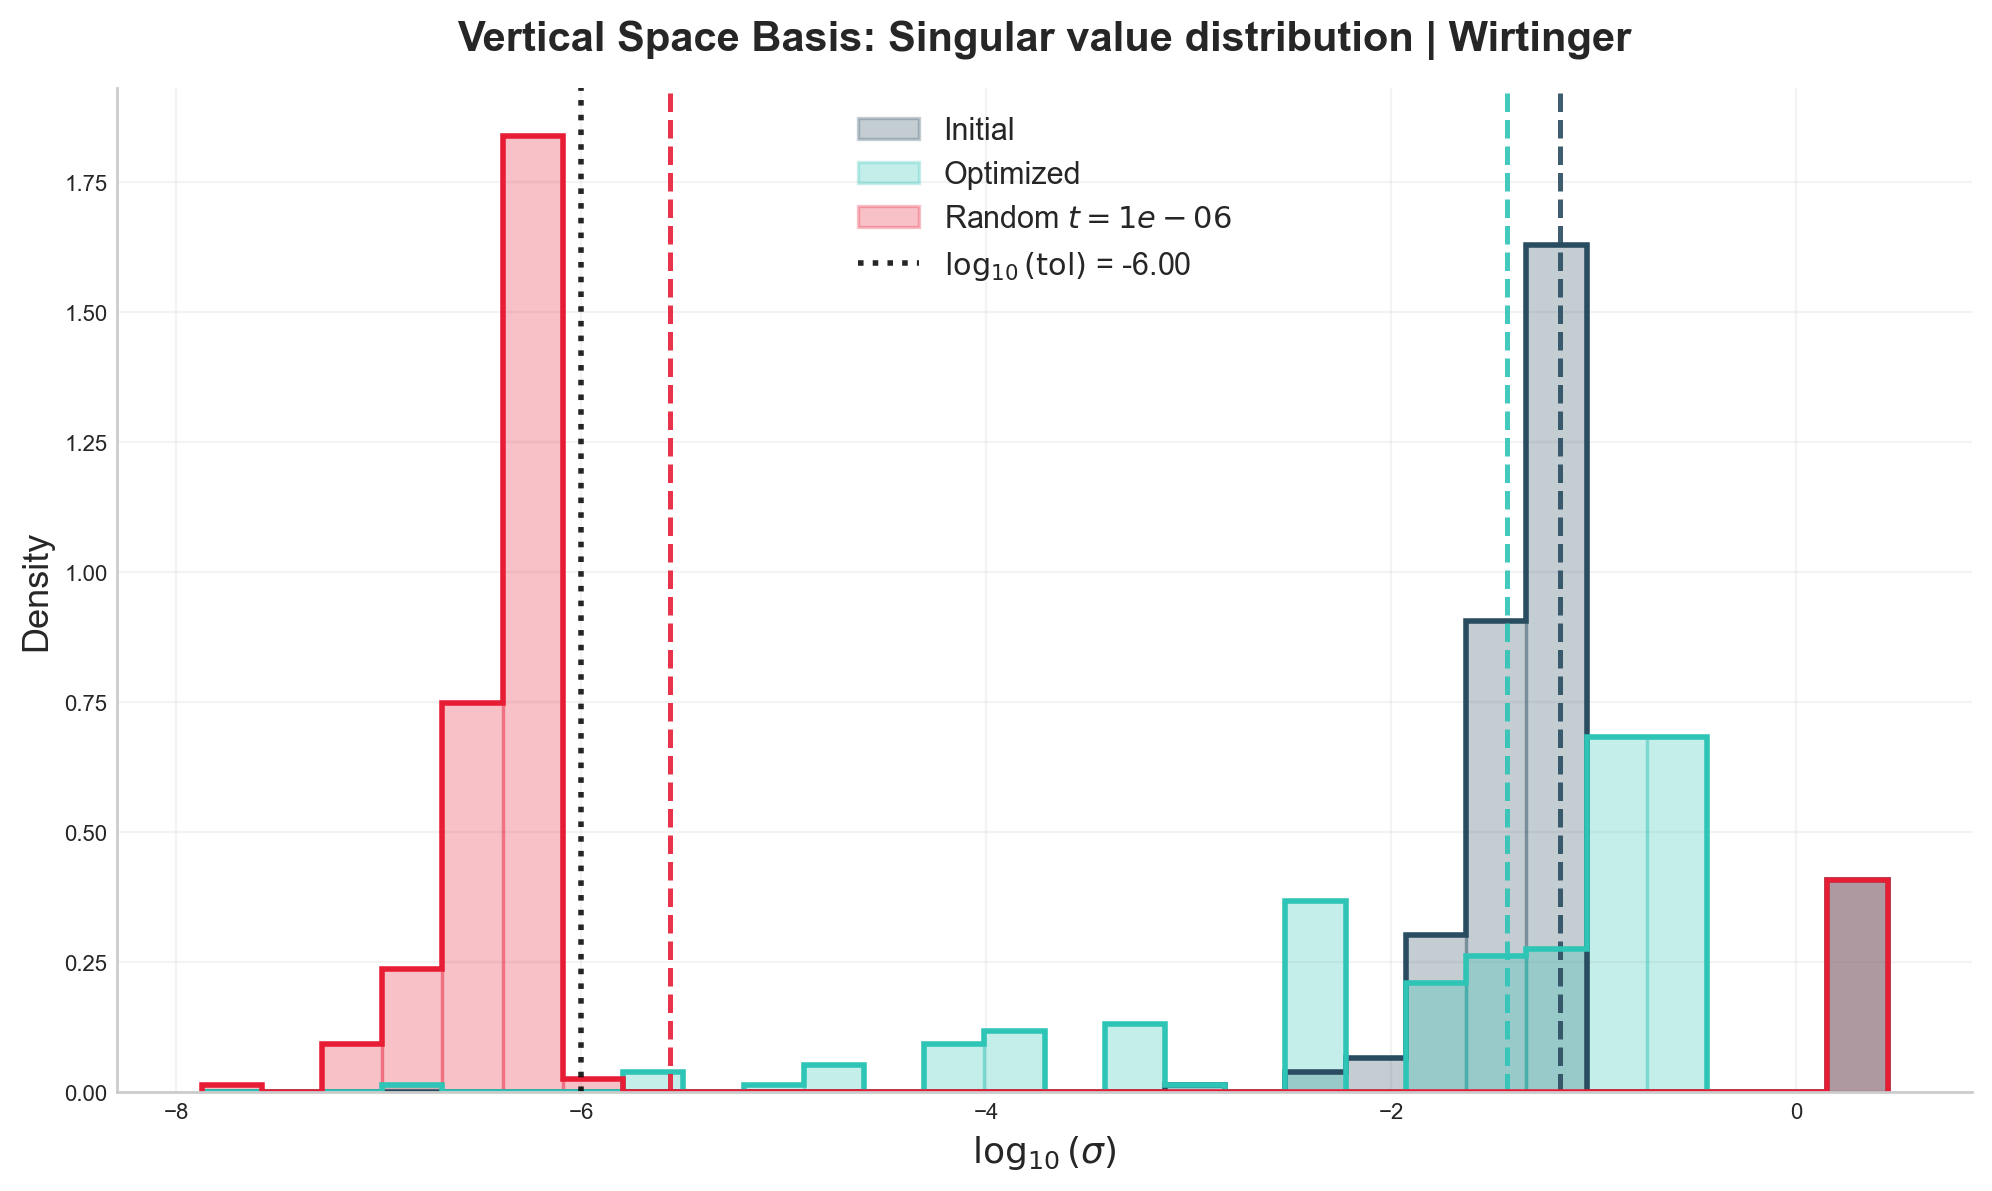

In [203]:
singular_values_dict = {
    "Initial": s_values_wirtinger,
    "Optimized": s_values_opt_wirtinger,
    rf"Random $t={step_size}$": s_values_rnd_wirtinger,
}

plot_singular_value_distributions(
    singular_values_dict,
    tol=tol,
    title="Vertical Space Basis: Singular value distribution | Wirtinger"
)

# $r = 8$

In [26]:
rank_8 = 8
n_rank_8 = dim_2q * rank_8

kraus_tensor_init_2q_rank_8 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=rank_8, seed=42)["kraus_tensor"]
gate_index = 0
x_init_rank_8 = kraus_tensor_init_2q_rank_8[gate_index]
x_isom_init_rank_8 = tensor_to_isometry(x_init_rank_8, n_rank_8, p)

vert_fund_vects_init_rank_8 = generate_vertical_fundamental_vectors(x=x_isom_init_rank_8, dim_A=rank_8)

vert_basis_init_rank_8_complex = vert_fund_vects_init_rank_8.reshape(vert_fund_vects_init_rank_8.shape[0], -1)
vert_basis_init_rank_8_wirtinger = jnp.concatenate([vert_basis_init_rank_8_complex, jnp.conj(vert_basis_init_rank_8_complex)], axis=1)

rank_init_rank_8_wirtinger, s_values_init_rank_8_wirtinger = compute_manual_rank(vert_basis_init_rank_8_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_init_rank_8_wirtinger)

Vertical space dimension:  64


In [27]:
random_kraus_tensor_rank8 = randKrausSet(num_gate_sequences=5, dim=dim_2q, rank_kraus=rank_8, a=step_size, seed=67)
x_rnd_rank8 = random_kraus_tensor_rank8[gate_index]
x_rnd_isom_rank8 = tensor_to_isometry(x_rnd_rank8, n_rank_8, p)
print(x_rnd_rank8.shape)

# construct the fundamental vertical vectors from this basis
vert_fund_vects_rnd_rank_8 = generate_vertical_fundamental_vectors(x=x_rnd_isom_rank8, dim_A=rank_8)
print(vert_fund_vects_rnd_rank_8.shape)
all(is_in_tangent_space(x=x_rnd_isom_rank8, z=v) for v in vert_fund_vects_rnd_rank_8)

vert_basis_rnd_complex_rank8 = vert_fund_vects_rnd_rank_8.reshape(vert_fund_vects_rnd_rank_8.shape[0], -1)
vert_basis_rnd_wirtinger_rank8 = jnp.concatenate([vert_basis_rnd_complex_rank8, jnp.conj(vert_basis_rnd_complex_rank8)], axis=1)

# This one here is just to test if this is half of the real ones.
rank_rnd_rank_8_complex, s_values_rnd_rank_8_complex= compute_manual_rank(vert_basis_rnd_complex_rank8, tol=tol)
print("Vertical space dimension: ", rank_rnd_rank_8_complex)

rank_rnd_rank_8_wirtinger, s_values_rnd_rank_8_wirtinger = compute_manual_rank(vert_basis_rnd_wirtinger_rank8, tol=tol)
print("Vertical space dimension: ", rank_rnd_rank_8_wirtinger)

(8, 4, 4)
(64, 32, 4)
Vertical space dimension:  8
Vertical space dimension:  15


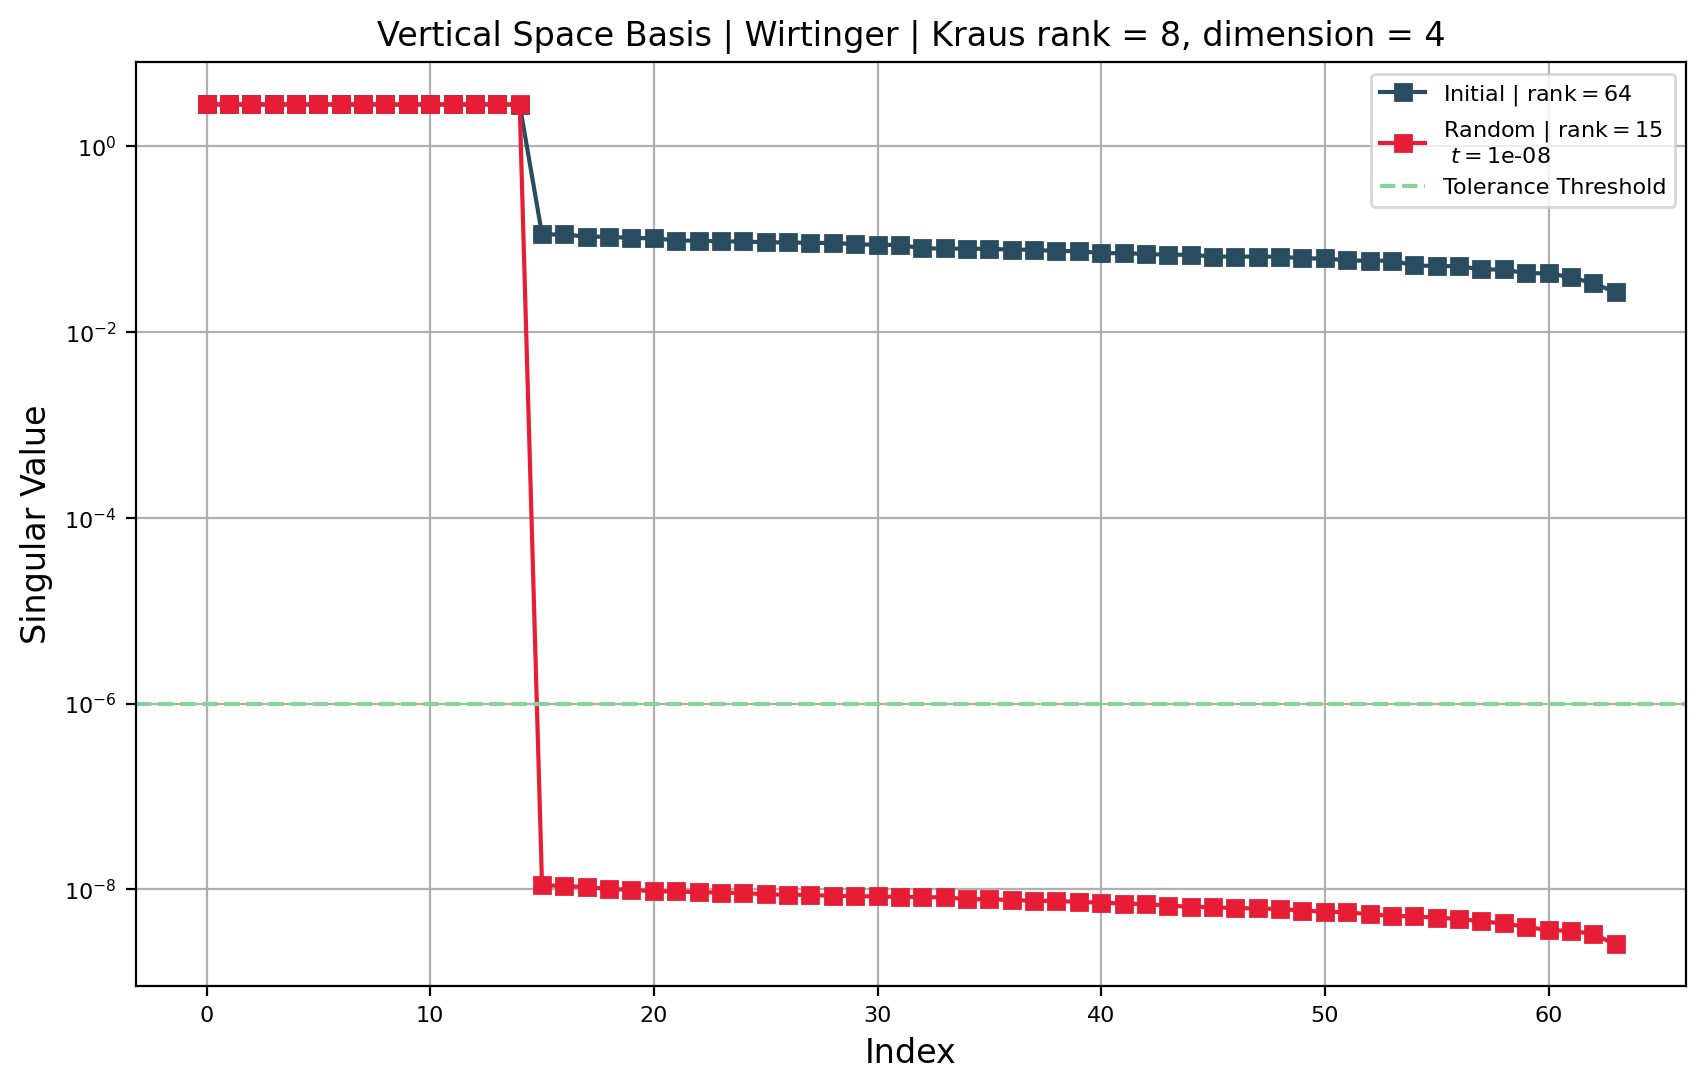

In [28]:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_init_rank_8_wirtinger, marker='s', label=r"Initial | $\mathrm{rank} = $" + f"{rank_init_rank_8_wirtinger}", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_rnd_rank_8_wirtinger, marker='s', label=r"Random | $\mathrm{rank} = $" + f"{rank_rnd_rank_8_wirtinger} \n" + r" $t=$" + f"{step_size}", color=COLOUR_PALETTE[2])
plt.axhline(tol, color=COLOUR_PALETTE[3], linestyle='--', label='Tolerance Threshold')
plt.title(f'Vertical Space Basis | Wirtinger | Kraus rank = {rank_8}, dimension = {dim_2q}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend(frameon=True)
plt.grid(True)
plt.show()

In [29]:
jnp.sum(s_values_rnd_rank_8_wirtinger > 1), jnp.sum(s_values_init_rank_8_wirtinger > 1)

(Array(15, dtype=int64), Array(15, dtype=int64))

## $r = 2$

In [30]:
rank_2 = 2
n_rank_2 = dim_2q * rank_2

kraus_tensor_init_2q_rank_2 = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=rank_2, seed=42)["kraus_tensor"]
gate_index = 0
x_init_rank_2 = kraus_tensor_init_2q_rank_2[gate_index]
x_isom_init_rank_2 = tensor_to_isometry(x_init_rank_2, n_rank_2, p)

vert_fund_vects_init_rank_2 = generate_vertical_fundamental_vectors(x=x_isom_init_rank_2, dim_A=rank_2)

vert_basis_init_rank_2_complex = vert_fund_vects_init_rank_2.reshape(vert_fund_vects_init_rank_2.shape[0], -1)
vert_basis_init_rank_2_wirtinger = jnp.concatenate([vert_basis_init_rank_2_complex, jnp.conj(vert_basis_init_rank_2_complex)], axis=1)

rank_init_rank_2_wirtinger, s_values_init_rank_2_wirtinger = compute_manual_rank(vert_basis_init_rank_2_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_init_rank_2_wirtinger)

Vertical space dimension:  4


In [31]:
random_kraus_tensor_rank_2 = randKrausSet(num_gate_sequences=5, dim=dim_2q, rank_kraus=rank_2, a=step_size, seed=67)
x_rnd_rank_2 = random_kraus_tensor_rank_2[gate_index]
x_rnd_isom_rank_2 = tensor_to_isometry(x_rnd_rank_2, n_rank_2, p)
print(x_rnd_rank_2.shape)

# construct the fundamental vertical vectors from this basis
vert_fund_vects_rnd_rank_2 = generate_vertical_fundamental_vectors(x=x_rnd_isom_rank_2, dim_A=rank_2)
print(vert_fund_vects_rnd_rank_2.shape)
all(is_in_tangent_space(x=x_rnd_isom_rank_2, z=v) for v in vert_fund_vects_rnd_rank_2)

vert_basis_rnd_complex_rank_2 = vert_fund_vects_rnd_rank_2.reshape(vert_fund_vects_rnd_rank_2.shape[0], -1)
vert_basis_rnd_wirtinger_rank_2 = jnp.concatenate([vert_basis_rnd_complex_rank_2, jnp.conj(vert_basis_rnd_complex_rank_2)], axis=1)

# This one here is just to test if this is half of the real ones.
rank_rnd_rank_2_complex, s_values_rnd_rank_2_complex= compute_manual_rank(vert_basis_rnd_complex_rank_2, tol=tol)
print("Vertical space dimension: ", rank_rnd_rank_2_complex)

rank_rnd_rank_2_wirtinger, s_values_rnd_rank_2_wirtinger = compute_manual_rank(vert_basis_rnd_wirtinger_rank_2, tol=tol)
print("Vertical space dimension: ", rank_rnd_rank_2_wirtinger)

(2, 4, 4)
(4, 8, 4)
Vertical space dimension:  2
Vertical space dimension:  3


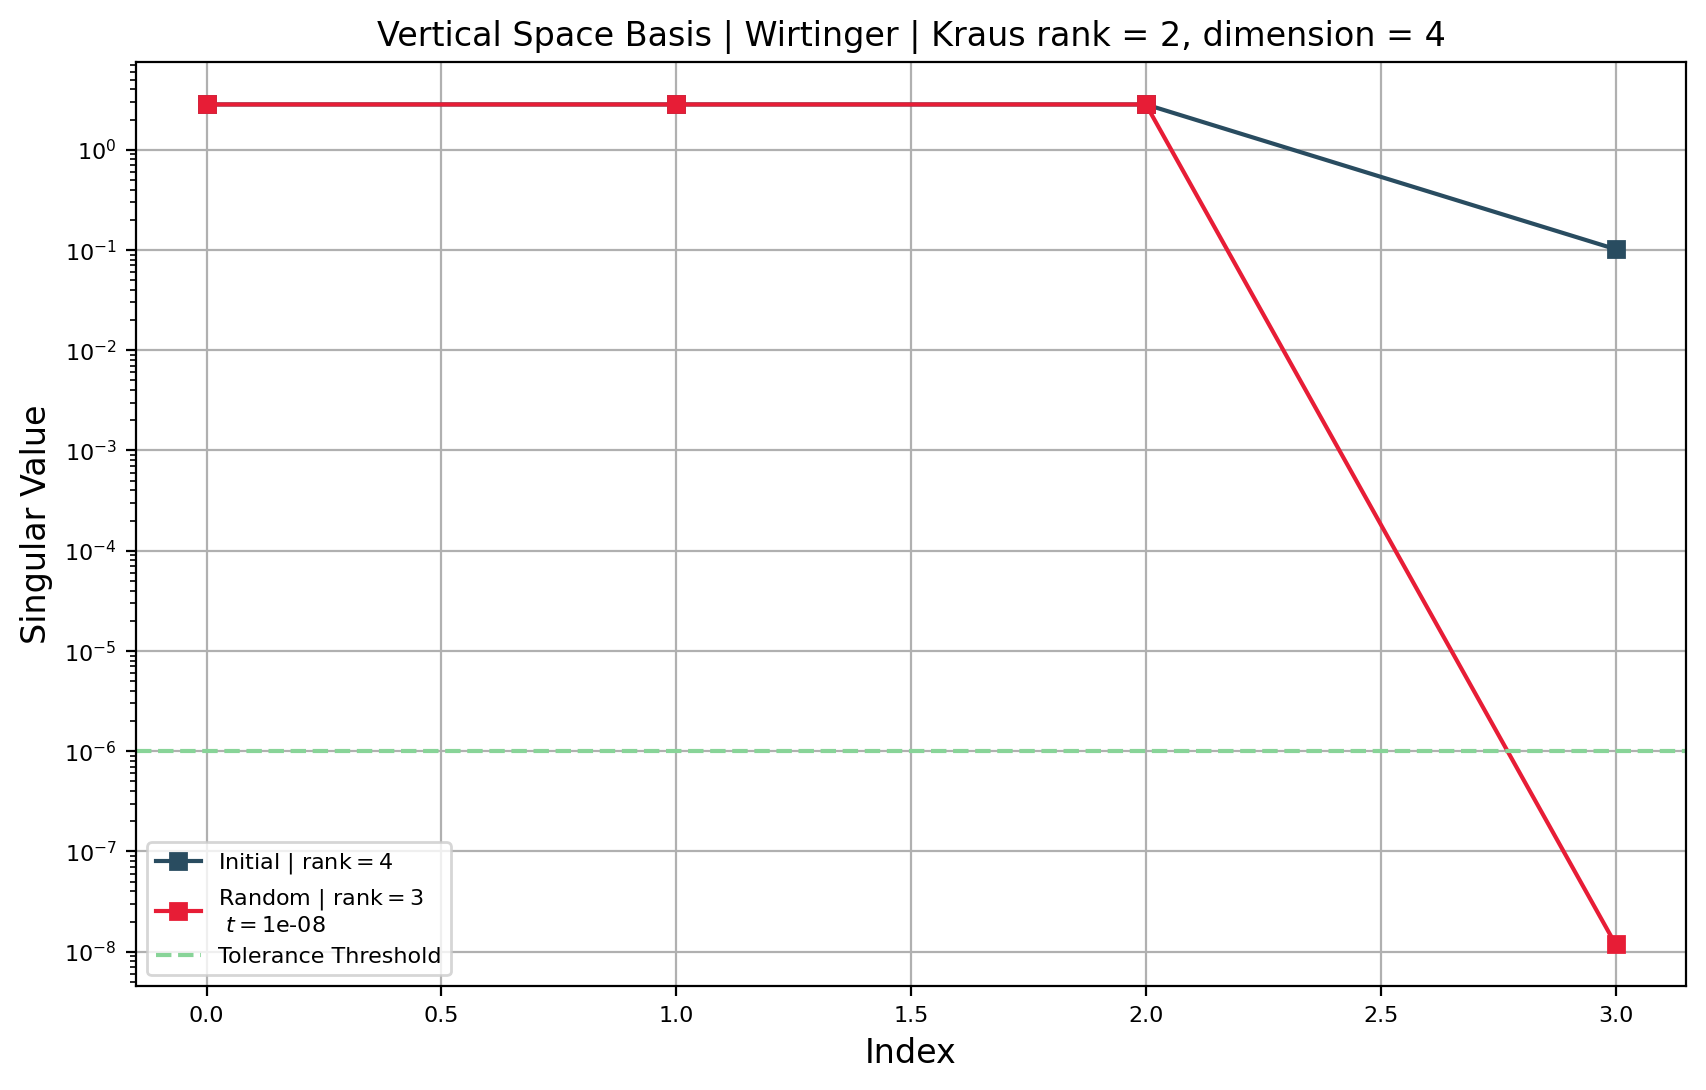

In [32]:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_init_rank_2_wirtinger, marker='s', label=r"Initial | $\mathrm{rank} = $" + f"{rank_init_rank_2_wirtinger}", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_rnd_rank_2_wirtinger, marker='s', label=r"Random | $\mathrm{rank} = $" + f"{rank_rnd_rank_2_wirtinger} \n" + r" $t=$" + f"{step_size}", color=COLOUR_PALETTE[2])
plt.axhline(tol, color=COLOUR_PALETTE[3], linestyle='--', label='Tolerance Threshold')
plt.title(f'Vertical Space Basis | Wirtinger | Kraus rank = {rank_2}, dimension = {dim_2q}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend(frameon=True)
plt.grid(True)
plt.show()

# $d = 2^3$

In [33]:
num_seq_3q = 1974

Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=num_seq_3q,
    shots=num_shots,
    rank=kraus_rank_4,
)

kraus_tensor_mgst_3q, kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, prob_matrix_3q, indices_list_3q = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend, only_jax_variables=True
)

2026-06-16 11:21:49,897 - iqm.benchmarks.logging_config - INFO - Generating 1974 random GST circuits
2026-06-16 11:21:50,681 - iqm.benchmarks.logging_config - INFO - Will transpile all 1974 circuits according to fixed physical layout
2026-06-16 11:21:51,458 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-06-16 11:21:56,566 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1974 circuits corresponding to qubits [0, 1, 3]
2026-06-16 11:21:56,568 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-06-16 11:21:56,638 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-06-16 11:21:56,708 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-06-16 11:21:58,938 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-06-16 11:22:06,280 - iqm.benchmarks.logging_config - INFO - Run c

In [34]:
# Obtain unperturbed Kraus
kraus_tensor_target_3q = target_kraus_tensor_from_configuration(Q3_GST, backend)
kraus_superop_target_3q = kraus_tensor_to_mgst(kraus_tensor_target_3q)
kraus_superop_target_3q.shape, kraus_tensor_target_3q.shape

((8, 64, 64), (8, 1, 8, 8))

In [35]:
dim_3q = 2 ** 3
rank_3q = 16
n_3q = dim_3q * rank_3q

kraus_tensor_init_3q = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target_3q, rank=rank_3q, seed=42)["kraus_tensor"]
gate_index = 0
x_init_3q = kraus_tensor_init_3q[gate_index]
x_isom_init_3q = tensor_to_isometry(x_init_3q, n_3q, dim_3q)

vert_fund_vects_init_3q = generate_vertical_fundamental_vectors(x=x_isom_init_3q, dim_A=rank_3q)

vert_basis_init_3q_complex = vert_fund_vects_init_3q.reshape(vert_fund_vects_init_3q.shape[0], -1)
vert_basis_init_3q_wirtinger = jnp.concatenate([vert_basis_init_3q_complex, jnp.conj(vert_basis_init_3q_complex)], axis=1)

rank_init_3q_wirtinger, s_values_init_3q_wirtinger = compute_manual_rank(vert_basis_init_3q_wirtinger, tol=tol)
print("Vertical space dimension: ", rank_init_3q_wirtinger)

Vertical space dimension:  256


In [36]:
random_kraus_tensor_3q = randKrausSet(num_gate_sequences=5, dim=dim_3q, rank_kraus=rank_3q, a=step_size, seed=67)
x_rnd_3q = random_kraus_tensor_3q[gate_index]
x_rnd_isom_3q = tensor_to_isometry(x_rnd_3q, n_3q, dim_3q)
print(x_rnd_3q.shape)

# construct the fundamental vertical vectors from this basis
vert_fund_vects_rnd_3q = generate_vertical_fundamental_vectors(x=x_rnd_isom_3q, dim_A=rank_3q)
print(vert_fund_vects_rnd_3q.shape)
all(is_in_tangent_space(x=x_rnd_isom_3q, z=v) for v in vert_fund_vects_rnd_3q)

vert_basis_rnd_complex_3q = vert_fund_vects_rnd_3q.reshape(vert_fund_vects_rnd_3q.shape[0], -1)
vert_basis_rnd_wirtinger_3q = jnp.concatenate([vert_basis_rnd_complex_3q, jnp.conj(vert_basis_rnd_complex_3q)], axis=1)

# This one here is just to test if this is half of the real ones.
rank_rnd_3q_complex, s_values_rnd_3q_complex= compute_manual_rank(vert_basis_rnd_complex_3q, tol=tol)
print("Vertical space dimension: ", rank_rnd_3q_complex)

rank_rnd_3q_wirtinger, s_values_rnd_3q_wirtinger = compute_manual_rank(vert_basis_rnd_wirtinger_3q, tol=tol)
print("Vertical space dimension: ", rank_rnd_3q_wirtinger)

(16, 8, 8)
(256, 128, 8)
Vertical space dimension:  16
Vertical space dimension:  31


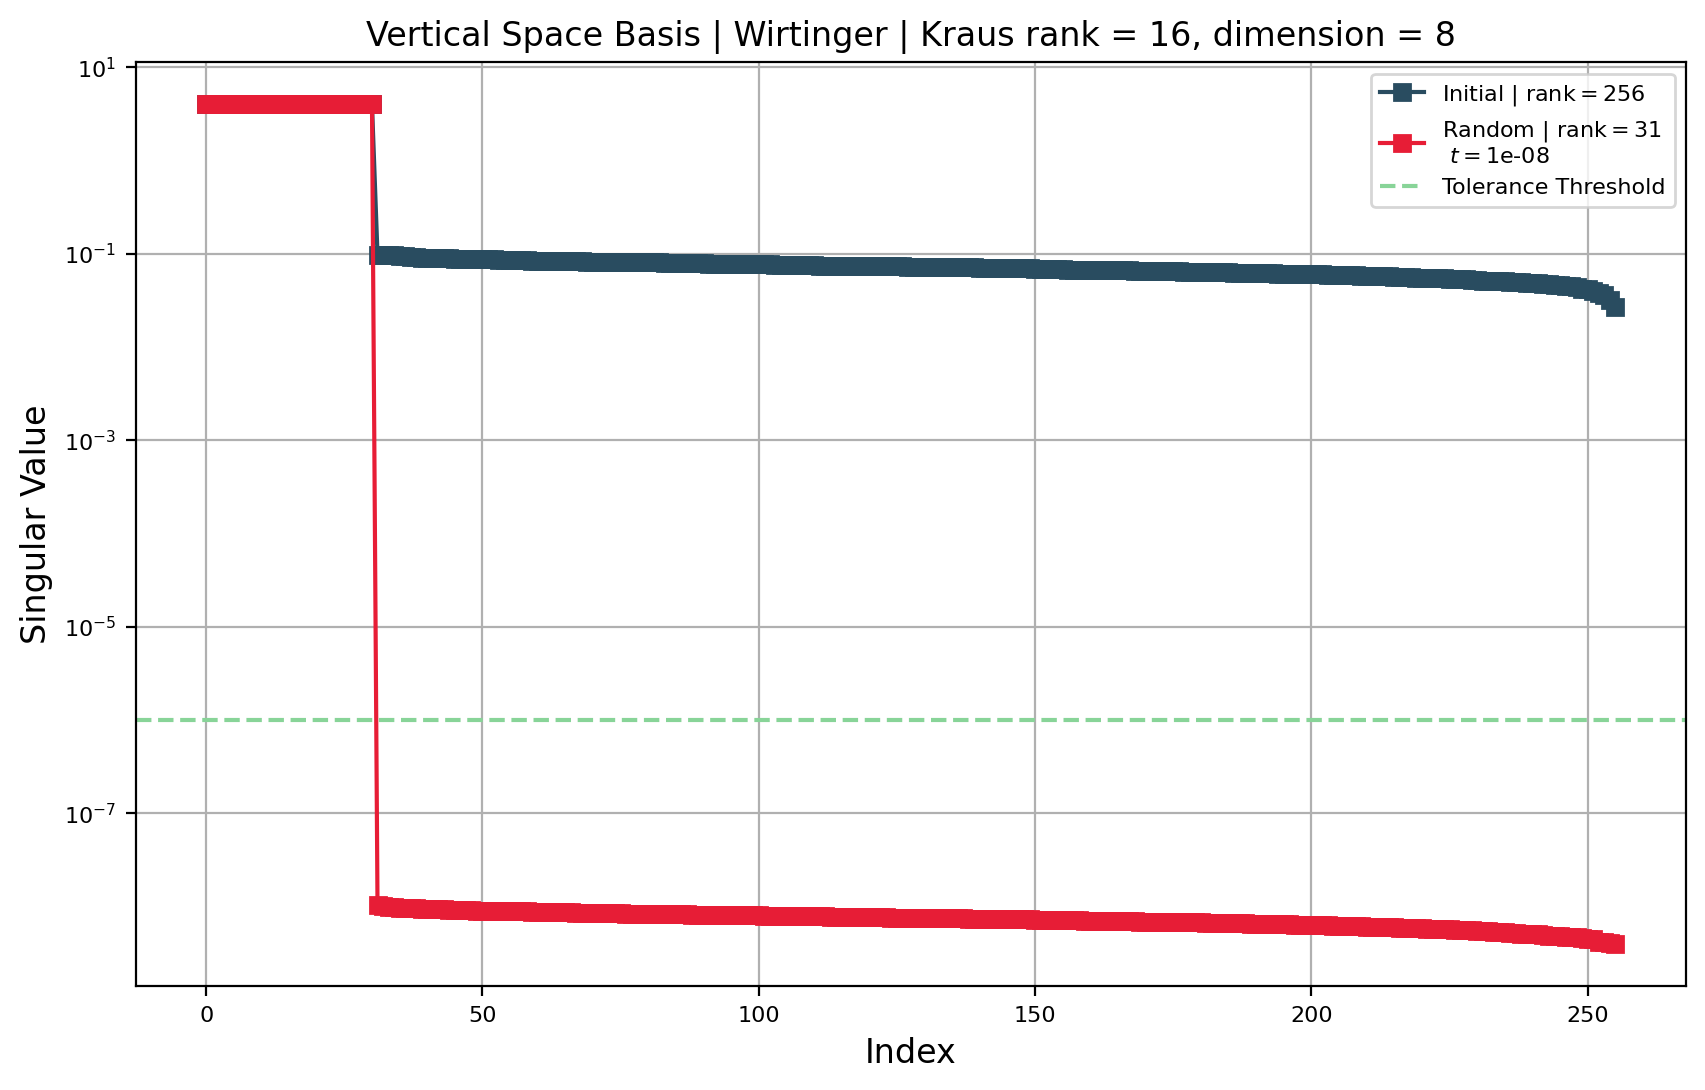

In [37]:
plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_init_3q_wirtinger, marker='s', label=r"Initial | $\mathrm{rank} = $" + f"{rank_init_3q_wirtinger}", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_rnd_3q_wirtinger, marker='s', label=r"Random | $\mathrm{rank} = $" + f"{rank_rnd_3q_wirtinger} \n" + r" $t=$" + f"{step_size}", color=COLOUR_PALETTE[2])
plt.axhline(tol, color=COLOUR_PALETTE[3], linestyle='--', label='Tolerance Threshold')
plt.title(f'Vertical Space Basis | Wirtinger | Kraus rank = {rank_3q}, dimension = {dim_3q}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend(frameon=True)
plt.grid(True)
plt.show()

In [38]:
# count the number of values that are greater than 1
jnp.sum(s_values_rnd_3q_wirtinger > 1), jnp.sum(s_values_init_3q_wirtinger > 1)

(Array(31, dtype=int64), Array(31, dtype=int64))

# Ideas:

1. Test if the behaviour is consistent among different gates at the same point from the kraus tensor. So, looking at other indices besides 0, will we also see consistently full rank for initial point and consistently lower rank for optimized point? If so, there is something there! If not, then what makes it have less rank?

    ✅ DONE: consistent behaviour among different gates. Moreover, consistent behaviour when varying the rank and the number of qubits. Always $2r-1$

2. Plot all 3 points in a single plot. Just to have an easier comparison.
    ✅ DONE

3. Play around with the random kraus tensor, specifically witht the parameter a. The closest to identity the less rank? Makes sense! (or does it)?

    * Currently looking at a = 0, which means that the Kraus operator is just an incomplete identity. What can I say from this?

# Continuing notebook

Goals:

Based on the discussion from 19.05.2026 (feels so long ago), we seem to understand why the rank when being at the identity (or super close to) gives $2r-1$, i.e. for $a \approx 0$. On the other extreme, we would expect for a random point far from the identity to have close to full rank (do we know exactly why?) --  I guess the idea is that it would be unlikely to have many linearly independent directions which related to the linear independence of the Kraus operators (see top of picture of white board)

1. Verify numerically that for $a \gg 0$, we obtain full rank, i.e. $\textrm{rank} = r^2$
    Answer: is not exactly full when looking only at eigenvalues greater than 1 but it is when having any threshold below 1e-2. Nicely, there is always one singular value that is smaller than the other ones, which would correspond to the trival stabilizer (identity - I think)
2. Verify numerically MPS degrees of freedom.

# Far from identity

## $r = 8$

In [56]:
with jnp.printoptions(precision=3, suppress=True):
    print(x_rnd_rank8[0])
# it is indeed k0 = Identity, and Kj = 0 for j > 0, as expected for a small step size.

[[ 1.+0.j -0.-0.j -0.-0.j -0.+0.j]
 [ 0.-0.j  1.+0.j  0.+0.j -0.-0.j]
 [ 0.-0.j -0.+0.j  1.-0.j  0.-0.j]
 [ 0.+0.j  0.-0.j -0.-0.j  1.-0.j]]


In [76]:
step_size_large = 1e1

random_kraus_tensor_far= randKrausSet(num_gate_sequences=5, dim=dim_2q, rank_kraus=rank_8, a=step_size_large, seed=67)
x_rnd_far = random_kraus_tensor_far[gate_index]

with jnp.printoptions(precision=3, suppress=True):
    print(x_rnd_far[2])

[[ 0.109+0.101j -0.139-0.241j -0.155-0.001j  0.246+0.326j]
 [-0.284-0.091j  0.002-0.187j -0.085+0.187j -0.09 -0.09j ]
 [-0.027+0.175j  0.102+0.109j -0.13 -0.147j  0.058+0.14j ]
 [-0.054+0.282j  0.   +0.035j -0.106-0.241j  0.038-0.134j]]


In [77]:
x_rnd_isom_far = tensor_to_isometry(x_rnd_far, n_rank_8, p)
# construct the fundamental vertical vectors from this basis
vert_fund_vects_rnd_far = generate_vertical_fundamental_vectors(x=x_rnd_isom_far, dim_A=rank_8)
print(vert_fund_vects_rnd_far.shape)
all(is_in_tangent_space(x=x_rnd_isom_far, z=v) for v in vert_fund_vects_rnd_far)

vert_basis_rnd_complex_far= vert_fund_vects_rnd_far.reshape(vert_fund_vects_rnd_far.shape[0], -1)
vert_basis_rnd_wirtinger_far = jnp.concatenate([vert_basis_rnd_complex_far, jnp.conj(vert_basis_rnd_complex_far)], axis=1)

rank_rnd_far_wirtinger, s_values_rnd_far_wirtinger = compute_manual_rank(vert_basis_rnd_wirtinger_far, tol=tol)
print("Vertical space dimension: ", rank_rnd_far_wirtinger)

(64, 32, 4)
Vertical space dimension:  64


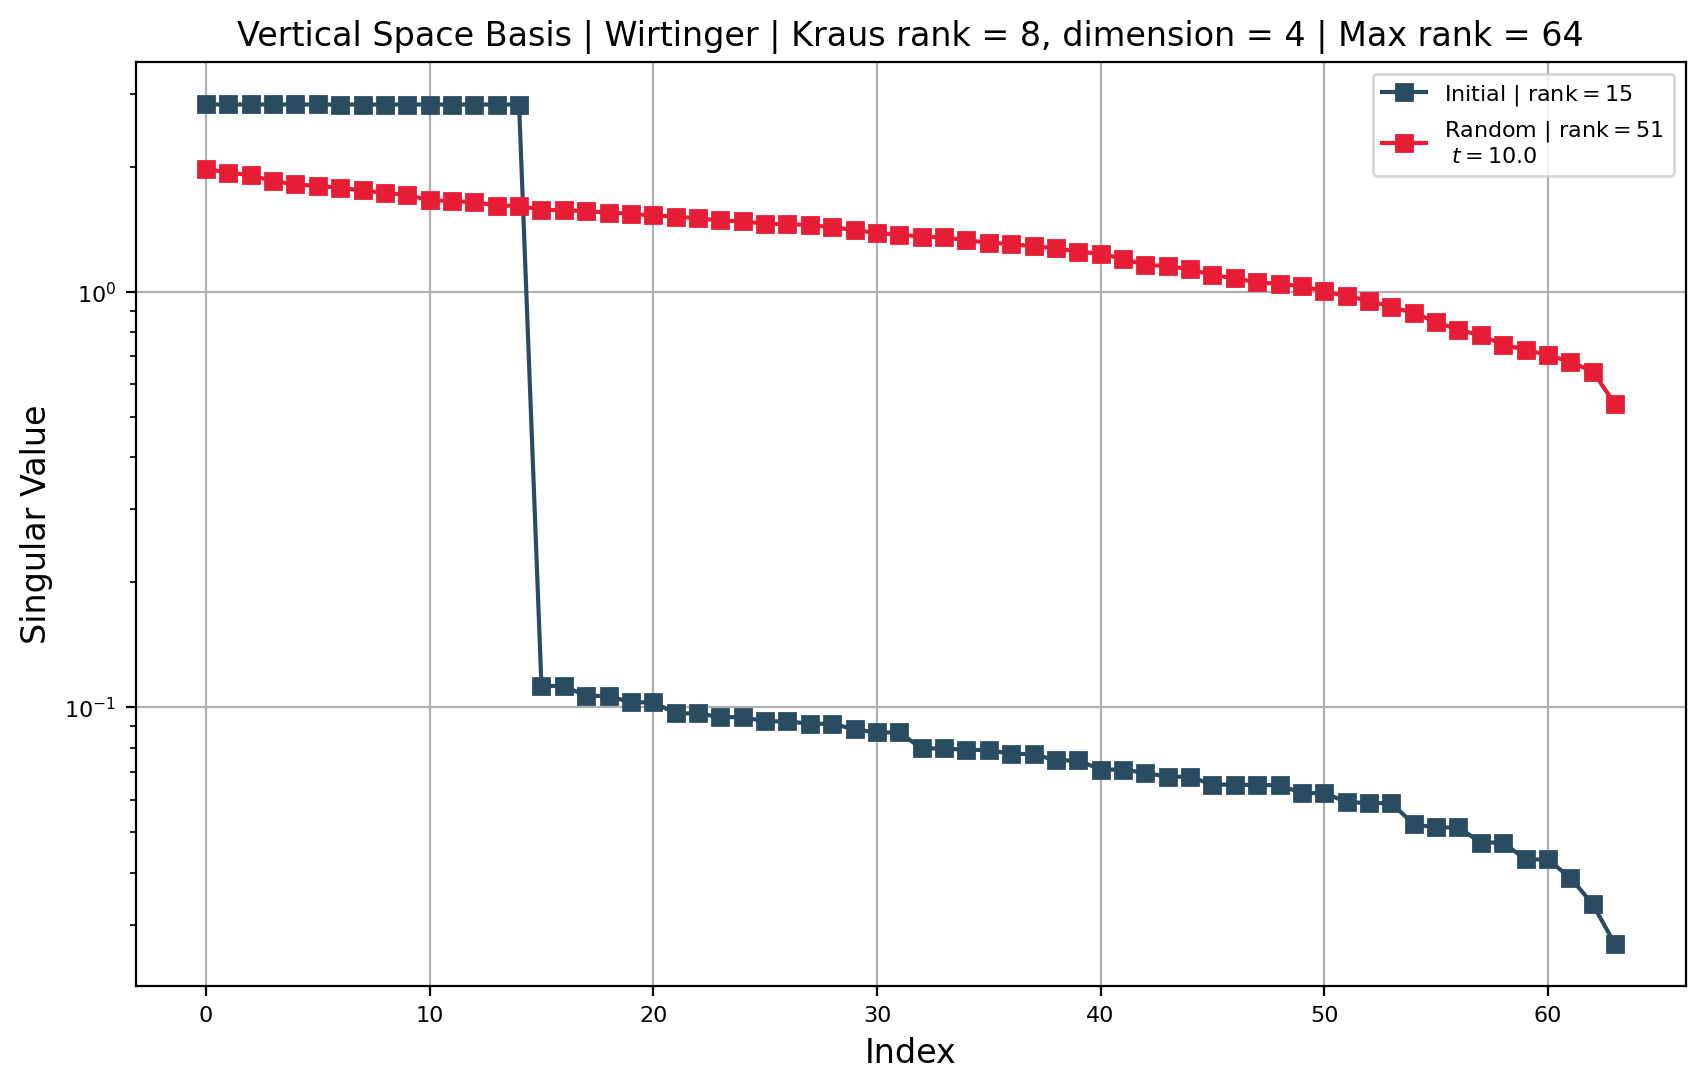

In [96]:
# rank defined as the number of singular values greater than 1
harsh_tol = 1.0
rank_rnd_far_wirtinger_harsh = jnp.sum(s_values_rnd_far_wirtinger > harsh_tol)
rank_init_rank_8_wirtinger_harsh = jnp.sum(s_values_init_rank_8_wirtinger > harsh_tol)
# So somehow is not full rank, but reaches 51 also. Under a different definition of the rank as greater than 0.1, this would indeed have full rank.

plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_init_rank_8_wirtinger, marker='s', label=r"Initial | $\mathrm{rank} = $" + f"{rank_init_rank_8_wirtinger_harsh}", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_rnd_far_wirtinger, marker='s', label=r"Random | $\mathrm{rank} = $" + f"{rank_rnd_far_wirtinger_harsh} \n" + r" $t=$" + f"{step_size_large}", color=COLOUR_PALETTE[2])
plt.title(f'Vertical Space Basis | Wirtinger | Kraus rank = {rank_8}, dimension = {dim_2q} | Max rank = {rank_8**2}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend(frameon=True)
plt.grid(True)
plt.show()

## $r = 16$

In [93]:
random_kraus_tensor_far_rank16= randKrausSet(num_gate_sequences=5, dim=dim_2q, rank_kraus=16, a=step_size_large, seed=67)
x_rnd_far_rank16 = random_kraus_tensor_far_rank16[gate_index]

x_rnd_isom_far_rank16 = tensor_to_isometry(x_rnd_far_rank16, n, p)
# construct the fundamental vertical vectors from this basis
vert_fund_vects_rnd_far_rank16 = generate_vertical_fundamental_vectors(x=x_rnd_isom_far_rank16, dim_A=16)
print(vert_fund_vects_rnd_far_rank16.shape)
all(is_in_tangent_space(x=x_rnd_isom_far_rank16, z=v) for v in vert_fund_vects_rnd_far_rank16)

vert_basis_rnd_complex_far_rank16= vert_fund_vects_rnd_far_rank16.reshape(vert_fund_vects_rnd_far_rank16.shape[0], -1)
vert_basis_rnd_wirtinger_far_rank16 = jnp.concatenate([vert_basis_rnd_complex_far_rank16, jnp.conj(vert_basis_rnd_complex_far_rank16)], axis=1)

rank_rnd_far_wirtinger_rank16, s_values_rnd_far_wirtinger_rank16 = compute_manual_rank(vert_basis_rnd_wirtinger_far_rank16, tol=tol)


(256, 64, 4)


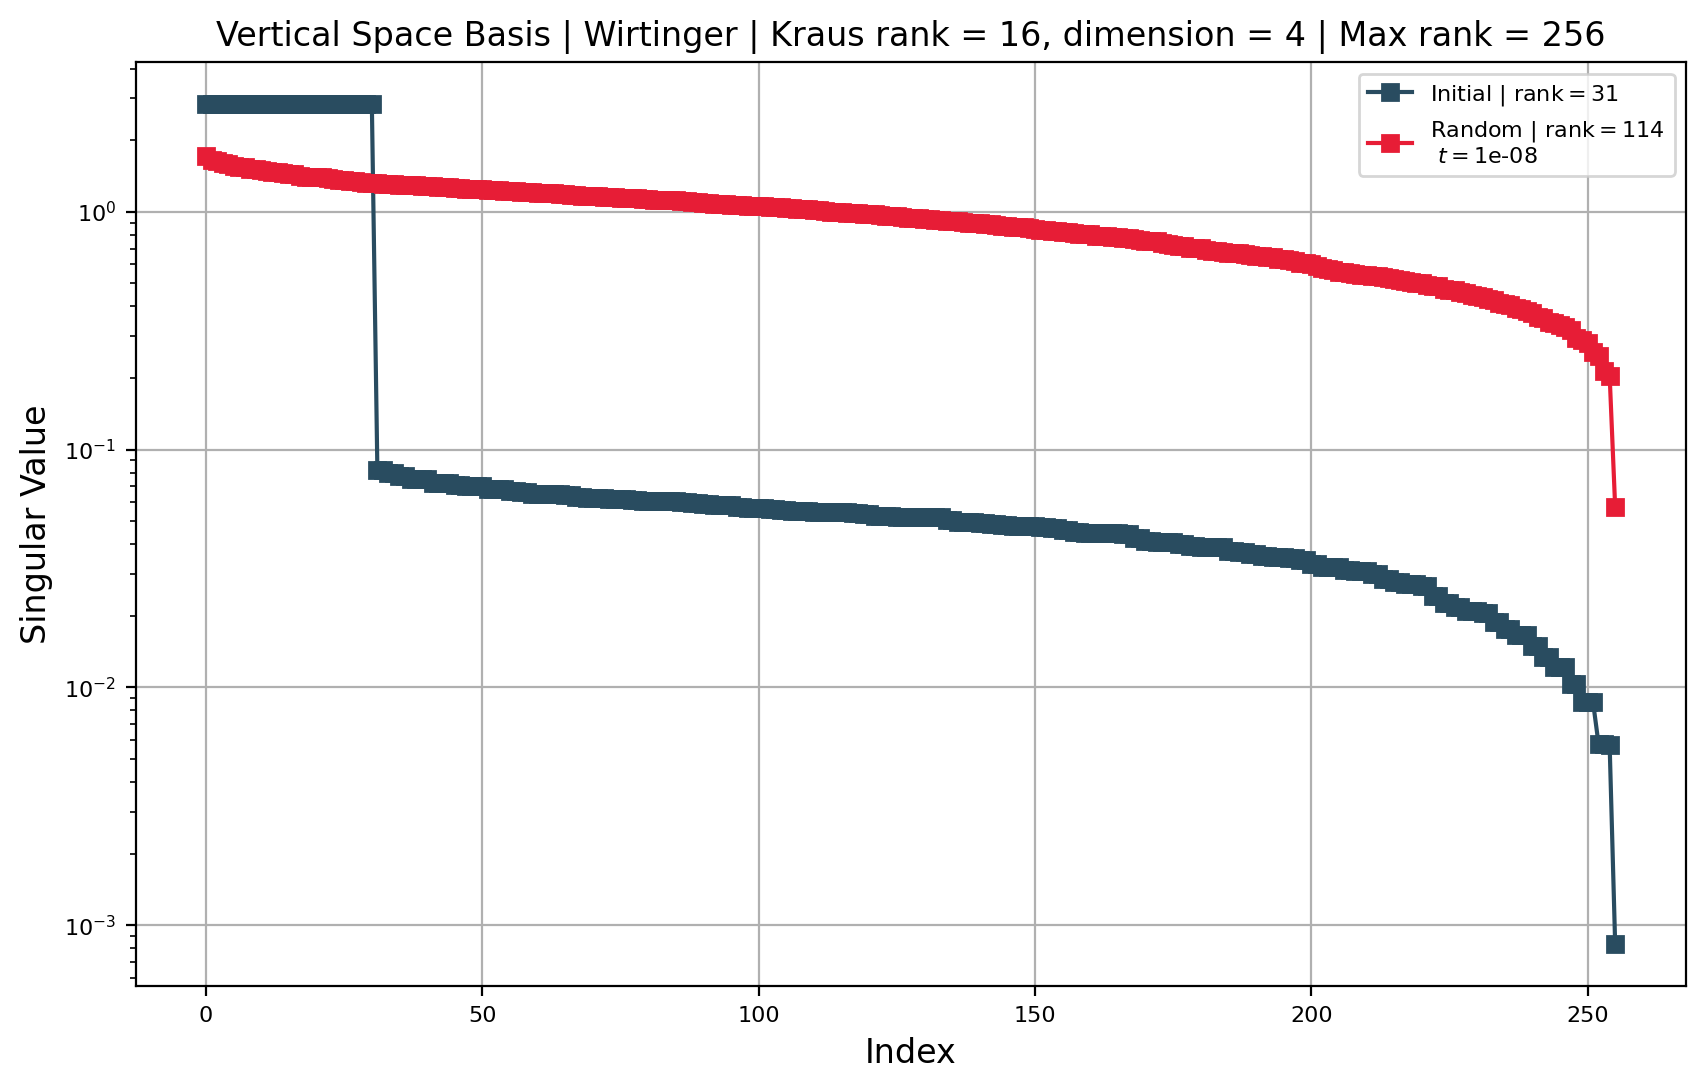

In [95]:
rank_rnd_far_wirtinger_harsh_rank16 = jnp.sum(s_values_rnd_far_wirtinger_rank16 > 1)
rank_init_rank_16_wirtinger_harsh = jnp.sum(s_values_wirtinger > harsh_tol)

plt.figure(figsize=(10, 6), dpi=200)
plt.semilogy(s_values_wirtinger, marker='s', label=r"Initial | $\mathrm{rank} = $" + f"{rank_init_rank_16_wirtinger_harsh}", color=COLOUR_PALETTE[0])
plt.semilogy(s_values_rnd_far_wirtinger_rank16, marker='s', label=r"Random | $\mathrm{rank} = $" + f"{rank_rnd_far_wirtinger_harsh_rank16} \n" + r" $t=$" + f"{step_size}", color=COLOUR_PALETTE[2])
plt.title(f'Vertical Space Basis | Wirtinger | Kraus rank = {16}, dimension = {dim_2q} | Max rank = {16**2}', fontsize=12)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Singular Value', fontsize=12)
plt.legend(frameon=True)
plt.grid(True)
plt.show()

# MPS degrees of freedom

In [98]:
# Let's start with the d=4, r=8 case.
vert_fund_vects_mps= generate_vertical_fundamental_vectors(x=x_isom_init_rank_8, dim_A=dim_2q, gauge_type="mps")

# Number of parameters

In [ ]:
from mGST.gauge_analysis import max_num_parameters, min_num_parameters

max_num_parameters(num_qubits=2, num_gates=6, kraus_rank=16)

239

In [30]:
min_num_parameters(num_qubits=4, num_gates=9, kraus_rank=2, state_rank=2, povm_rank=2)

7383

In [78]:
min_num_parameters(num_qubits=4, num_gates=9, kraus_rank=4, state_rank=4, povm_rank=4)

17375

In [32]:
min_num_parameters(num_qubits=4, num_gates=9, kraus_rank=4)

19823

In [33]:
min_num_parameters(num_qubits=3, num_gates=8, kraus_rank="max")

32703

In [34]:
min_num_parameters(num_qubits=3, num_gates=8, kraus_rank=4)

3903

In [26]:
min_num_parameters(num_qubits=2, num_gates=8, kraus_rank="max", verbose=True)

Gauge-invariant dimensions: POVM=48, Gates=1920, State=15


1967

In [69]:
from mGST.gauge_analysis import dim_stiefel_tangent_space, unitary_group_dimension
def kraus_parameters(num_qubits, num_gates, kraus_rank):
    dim = 2 ** num_qubits
    dim_gates = num_gates * dim_stiefel_tangent_space(dim*kraus_rank, dim)
    gauge_gates = num_gates * unitary_group_dimension(kraus_rank)
    return dim_gates - gauge_gates
    
num_qubits = 3
num_gates = 8
d_4q = 2 ** num_qubits
ranks_4q = jnp.arange(1, d_4q**2+1, 1)
state_rank, povm_rank = None, None # to set them up to max
min_params = [
    kraus_parameters(num_qubits=num_qubits,
                       num_gates=num_gates,
                       kraus_rank=r)
    for r in ranks_4q]
len(ranks_4q)

64

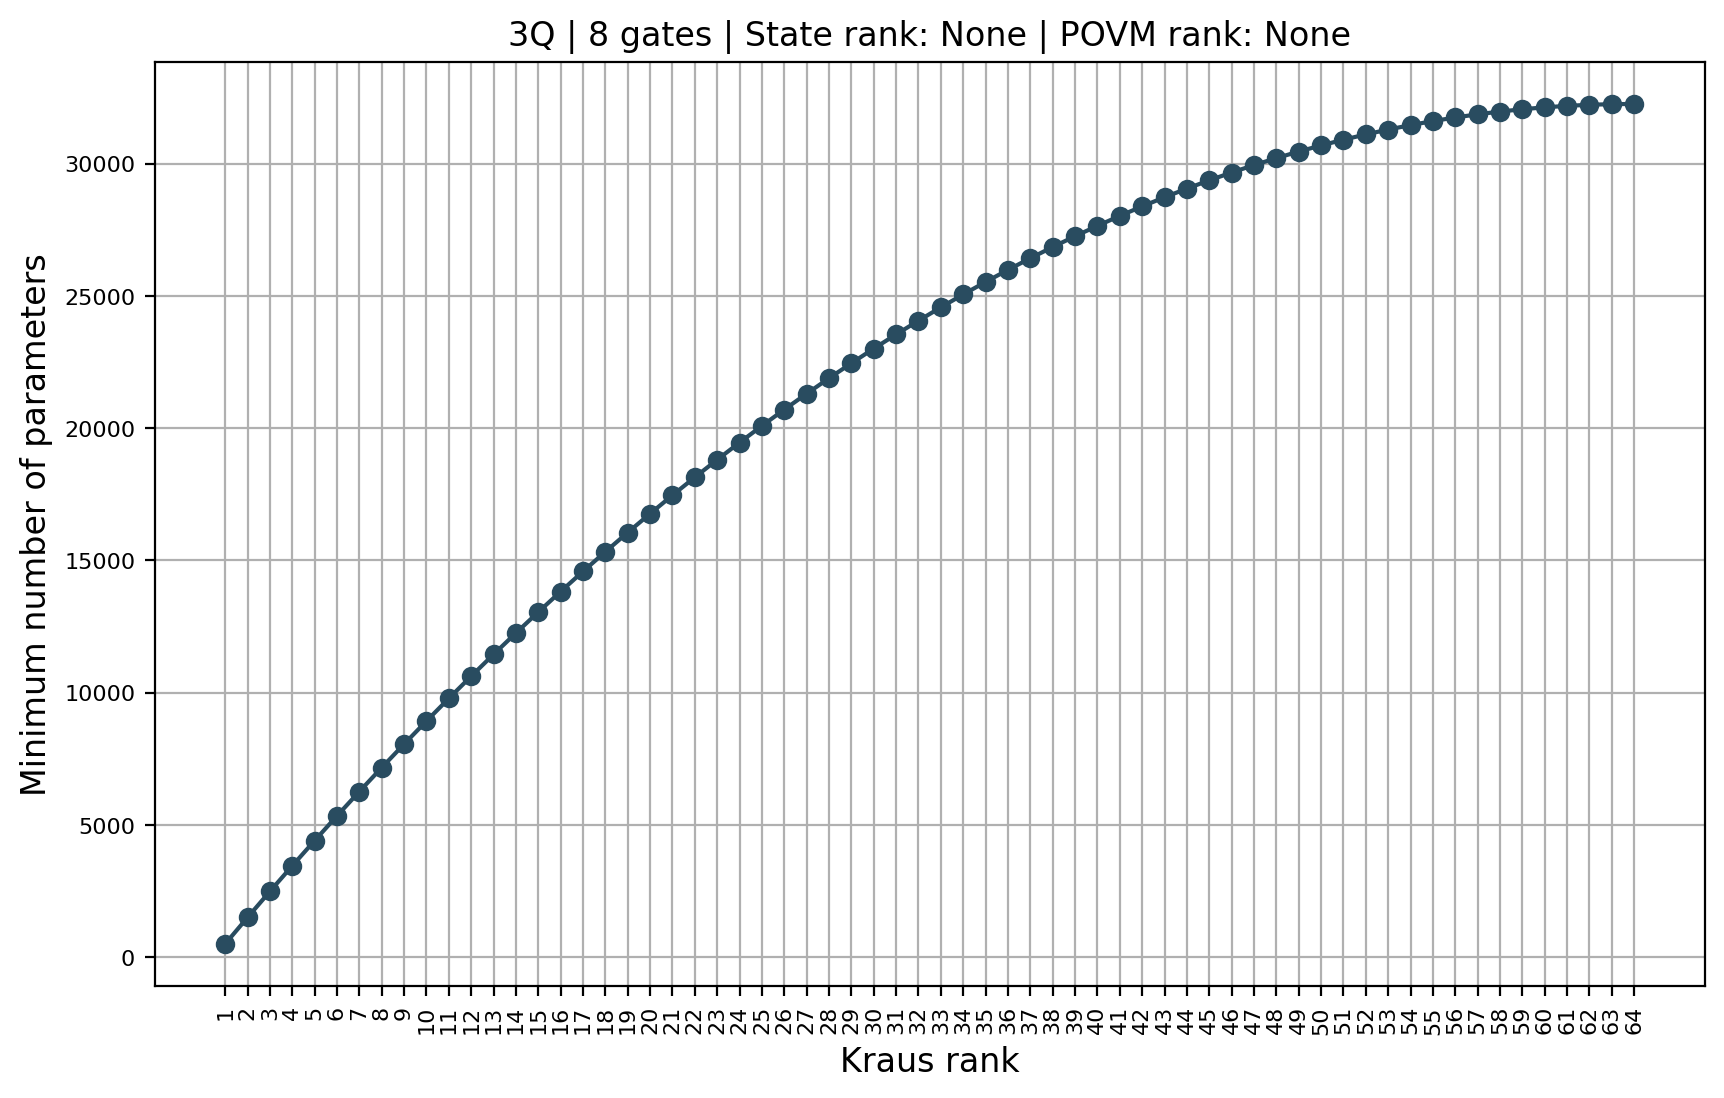

In [70]:
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(ranks_4q, min_params, marker='o', color=COLOUR_PALETTE[0])
plt.title(f'{num_qubits}Q | {num_gates} gates | State rank: {state_rank} | POVM rank: {povm_rank}', fontsize=12)
plt.xlabel('Kraus rank', fontsize=12)
plt.ylabel('Minimum number of parameters', fontsize=12)
plt.grid(True)
plt.xticks(ranks_4q, rotation=90)
plt.show()

In [77]:
num_qubits = 1
num_gates = 3
print(f"Num qubits: {num_qubits}, Num gates: {num_gates}")
print(min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=1))
print(min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank="max"))

num_qubits = 2
num_gates = 6
print(f"Num qubits: {num_qubits}, Num gates: {num_gates}")
print(min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=1))
print(min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank="max"))

num_qubits = 3
num_gates = 8
print(f"Num qubits: {num_qubits}, Num gates: {num_gates}")
print(min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=1))
print(min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank="max"))

num_qubits = 4
num_gates = 9
print(f"Num qubits: {num_qubits}, Num gates: {num_gates}")
print(min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=1))
print(min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank="max"))

Num qubits: 1, Num gates: 3
12
39
Num qubits: 2, Num gates: 6
137
1487
Num qubits: 3, Num gates: 8
951
32703
Num qubits: 4, Num gates: 9
6134
591359


In [79]:
num_qubits = 4
num_gates = 9
ranks = [1, 2, 4, 8]

for r_k in ranks:
    for r_ba in ranks:
        mx = max_num_parameters(num_qubits, num_gates, r_k, state_rank=r_ba, povm_rank=r_ba)
        mn = min_num_parameters(num_qubits, num_gates, r_k, state_rank=r_ba, povm_rank=r_ba)
        print(f"r_K={r_k}, r_BA={r_ba}: max={mx}, min={mn}")


r_K=1, r_BA=1: max=2591, min=2309
r_K=1, r_BA=2: max=3135, min=2802
r_K=1, r_BA=4: max=4223, min=3686
r_K=1, r_BA=8: max=6399, min=5046
r_K=2, r_BA=1: max=7199, min=6890
r_K=2, r_BA=2: max=7743, min=7383
r_K=2, r_BA=4: max=8831, min=8267
r_K=2, r_BA=8: max=11007, min=9627
r_K=4, r_BA=1: max=16415, min=15998
r_K=4, r_BA=2: max=16959, min=16491
r_K=4, r_BA=4: max=18047, min=17375
r_K=4, r_BA=8: max=20223, min=18735
r_K=8, r_BA=1: max=34847, min=33998
r_K=8, r_BA=2: max=35391, min=34491
r_K=8, r_BA=4: max=36479, min=35375
r_K=8, r_BA=8: max=38655, min=36735


In [82]:
d = 2 ** num_qubits
max_num_parameters(num_qubits, num_gates, 1, state_rank=d, povm_rank=d)


10751

In [83]:
min_num_parameters(num_qubits, num_gates, 1, state_rank=d, povm_rank=d)


6134